# **A Federated Foundation Model Framework with MobileMambaServantNet for Trust-Aware Red-Tape Analysis and Citizen-Rated Local Government Service Quality**

# Install Library

In [5]:
!pip install presidio-analyzer presidio-anonymizer

# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/Dataset/municipal_training_set_1100.csv'
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()


Dataset Shape: (1100, 26)

First 5 rows:


,report_id,resident_id,resident_name,resident_email,resident_phone,issue_type,issue_description,issue_status,report_datetime,location_street_address,...,photo_url,municipal_department,resolution_datetime,resolution_notes,is_anonymous,priority_level,priority_score,severity_score,area_importance,citizen_reports_count
0,RPT-354769,RES-1028,Jack Hernandez,jack.hernandez28@example.com,+1-758-555-1049,noise,Unauthorized late-night party with amplified s...,resolved,2025-10-21T19:29:14.031832,3422 Sunset Blvd,...,NaN,Public Safety,2025-10-30T19:29:14.031832,Resolved by field unit.,True,low,3.08,2,7,3
1,RPT-928980,RES-6964,NaN,NaN,NaN,pothole,Deep pothole near the bus stop making it dange...,in-progress,2023-07-10T08:15:00,1200 W 87th St,...,https://cityreports.com/photos/pothole1200.jpg,Road Maintenance,NaN,NaN,True,medium,6.30,9,7,10
2,RPT-337675,RES-2013,William Gonzalez,william.gonzalez@example.com,+1-362-555-3105,noise,Construction crew is starting their work at 5 ...,in-progress,2025-07-11T00:00:00,9390 Cedar Ln,...,NaN,Public Safety,NaN,NaN,False,medium,6.02,5,7,32
3,RPT-528487,RES-5089,Patricia Davis,patricia.davis104@mail.com,+1-380-555-5810,water_leakage,URGENT: A significant water leak near the scho...,submitted,2025-06-15T00:00:00,1254 Oak Rd,...,https://civicphotos.gov.us/water_leakage-RPT-5...,Water Department,NaN,NaN,False,high,7.72,7,9,37
4,RPT-609991,RES-1044,Susan Williams,susan.williams26@example.com,+1-281-555-1496,pothole,Can someone please fix a small pothole that is...,submitted,2025-05-12T19:27:31.182002,8226 Cedar Dr,...,NaN,Roads & Highways,NaN,NaN,True,low,3.46,4,4,11



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   report_id                1100 non-null   object 
 1   resident_id              1100 non-null   object 
 2   resident_name            1037 non-null   object 
 3   resident_email           1037 non-null   object 
 4   resident_phone           1022 non-null   object 
 5   issue_type               1100 non-null   object 
 6   issue_description        1100 non-null   object 
 7   issue_status             1100 non-null   object 
 8   report_datetime          1100 non-null   object 
 9   location_street_address  1100 non-null   object 
 10  location_city            1100 non-null   object 
 11  location_state           1100 non-null   object 
 12  location_postal_code     1100 non-null   int64  
 13  location_country         1100 non-null   object 
 14  latitude 

# Preprocess


# Microsoft Presidio NER

In [8]:
import pandas as pd
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
import logging


logging.getLogger("presidio-analyzer").setLevel(logging.ERROR)

analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

pii_columns = ['resident_name', 'resident_email', 'resident_phone', 'street_address']
active_pii_cols = [col for col in pii_columns if col in df.columns]

df_clean = df.copy()

def remove_pii(text):
    if pd.isna(text):
        return text
    analysis_results = analyzer.analyze(text=str(text), language='en')
    anonymized_result = anonymizer.anonymize(text=str(text), analyzer_results=analysis_results)
    return anonymized_result.text

for col in active_pii_cols:
    df_clean[col] = df_clean[col].apply(remove_pii)

print("--- BEFORE PII REMOVAL ---")
display(df[active_pii_cols].head(3))

print("\n--- AFTER PII REMOVAL via Presidio  ---")
display(df_clean[active_pii_cols].head(3))

--- BEFORE PII REMOVAL (Sample) ---


,resident_name,resident_email,resident_phone
0,Jack Hernandez,jack.hernandez28@example.com,+1-758-555-1049
1,NaN,NaN,NaN
2,William Gonzalez,william.gonzalez@example.com,+1-362-555-3105



--- AFTER PII REMOVAL via Presidio (Sample) ---


,resident_name,resident_email,resident_phone
0,<PERSON>,<EMAIL_ADDRESS>,+1-758-555-1049
1,NaN,NaN,NaN
2,<PERSON>,<EMAIL_ADDRESS>,+1-362-555-3105


# SHA-256 Hashing

In [9]:
import hashlib

def hash_resident_id(resident_id):
    if pd.isna(resident_id):
        return resident_id
    return hashlib.sha256(str(resident_id).encode('utf-8')).hexdigest()

if 'resident_id' in df_clean.columns:
    original_ids = df_clean['resident_id'].copy()
    df_clean['resident_id'] = df_clean['resident_id'].apply(hash_resident_id)

    comparison_df = pd.DataFrame({
        'Original_resident_id': original_ids,
        'Hashed_resident_id': df_clean['resident_id']
    })

    print("--- RESIDENT ID PSEUDONYMIZATION (SHA-256) ---")
    display(comparison_df.head(3))
else:
    print("Column 'resident_id' not found in the dataframe.")

--- RESIDENT ID PSEUDONYMIZATION (SHA-256) ---


,Original_resident_id,Hashed_resident_id
0,RES-1028,09b215a6ec9776213e2a6307ab27f5c4344d6aaefb8dea...
1,RES-6964,61395bfb3dc4a394281e577631e48b9a3bbbe474b115ef...
2,RES-2013,86aafdf9e6fa532151b68dad8b98aaad28c42832a3dc05...


# Duplicate Record Detection

In [10]:
initial_count = len(df_clean)

duplicate_mask = df_clean.duplicated(keep='first')
num_duplicates = duplicate_mask.sum()

if num_duplicates > 0:
    print(f"--- Found {num_duplicates} duplicate record(s) ---")
    display(df_clean[duplicate_mask].head(3))
else:
    print("--- No duplicate records found. Dataset is already unique. ---")

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"\n--- DUPLICATE REMOVAL SUMMARY ---")
print(f"Initial Rows: {initial_count}")
print(f"Rows Removed: {num_duplicates}")
print(f"Final Unique Rows: {len(df_clean)}")

--- No duplicate records found. Dataset is already unique. ---

--- DUPLICATE REMOVAL SUMMARY ---
Initial Rows: 1100
Rows Removed: 0
Final Unique Rows: 1100


#  KNN Imputation

In [11]:
from sklearn.impute import KNNImputer
import numpy as np

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("--- Missing Numerical Values BEFORE Imputation ---")
missing_before = df_clean[numerical_cols].isnull().sum()
print(missing_before[missing_before > 0] if not missing_before[missing_before > 0].empty else "No missing values found in numerical columns.")

imputer = KNNImputer(n_neighbors=5)
df_clean[numerical_cols] = imputer.fit_transform(df_clean[numerical_cols])

print("\n--- Missing Numerical Values AFTER KNN Imputation ---")
missing_after = df_clean[numerical_cols].isnull().sum()
print(f"Total remaining missing values: {missing_after.sum()}")

print("\n--- Final Privacy-Preserved Complaint Dataset ---")
display(df_clean.head(3))
print(f"Final Dataset Dimensions: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

--- Missing Numerical Values BEFORE Imputation ---
No missing values found in numerical columns.

--- Missing Numerical Values AFTER KNN Imputation ---
Total remaining missing values: 0

--- Final Privacy-Preserved Complaint Dataset ---


,report_id,resident_id,resident_name,resident_email,resident_phone,issue_type,issue_description,issue_status,report_datetime,location_street_address,...,resolution_datetime,resolution_notes,is_anonymous,priority_level,priority_score,severity_score,area_importance,citizen_reports_count,resident_name_redacted,resident_email_redacted
0,RPT-354769,09b215a6ec9776213e2a6307ab27f5c4344d6aaefb8dea...,<PERSON>,<EMAIL_ADDRESS>,+1-758-555-1049,noise,Unauthorized late-night party with amplified s...,resolved,2025-10-21T19:29:14.031832,3422 Sunset Blvd,...,2025-10-30T19:29:14.031832,Resolved by field unit.,True,low,3.08,2.0,7.0,3.0,<PERSON>,<EMAIL_ADDRESS>
1,RPT-928980,61395bfb3dc4a394281e577631e48b9a3bbbe474b115ef...,NaN,NaN,NaN,pothole,Deep pothole near the bus stop making it dange...,in-progress,2023-07-10T08:15:00,1200 W 87th St,...,NaN,NaN,True,medium,6.30,9.0,7.0,10.0,nan,nan
2,RPT-337675,86aafdf9e6fa532151b68dad8b98aaad28c42832a3dc05...,<PERSON>,<EMAIL_ADDRESS>,+1-362-555-3105,noise,Construction crew is starting their work at 5 ...,in-progress,2025-07-11T00:00:00,9390 Cedar Ln,...,NaN,NaN,False,medium,6.02,5.0,7.0,32.0,<PERSON>,<EMAIL_ADDRESS>


Final Dataset Dimensions: 1100 rows, 28 columns


# Distribution of Complaint Issue Types

/tmp/ipykernel_1984/3226707406.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='issue_type', order=df_clean['issue_type'].value_counts().index, palette='viridis')


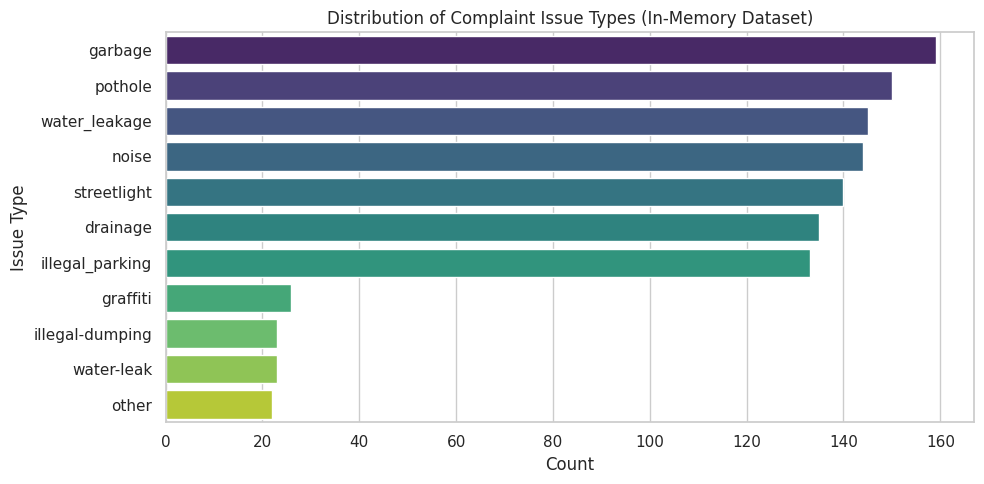

Dataset remains stored purely in the `df_clean` variable (1100 rows, 28 columns). Ready for the next step.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y='issue_type', order=df_clean['issue_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Complaint Issue Types')
plt.xlabel('Count')
plt.ylabel('Issue Type')
plt.tight_layout()
plt.show()

print(f"Dataset remains stored purely in the `df_clean` variable ({df_clean.shape[0]} rows, {df_clean.shape[1]} columns). Ready for the next step.")

# Split Datset

In [65]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

target_col = 'priority_level'

drop_cols = [
    target_col, 'report_id', 'resident_id', 'resident_name', 'resident_email',
    'resident_phone', 'street_address', 'issue_description', 'report_datetime',
    'location_street_address', 'resolution_datetime', 'resolution_notes',
    'resident_name_redacted', 'resident_email_redacted'
]

feature_cols = [col for col in df_clean.columns if col not in drop_cols]
X = df_clean[feature_cols].select_dtypes(include=[np.number])
y = df_clean[target_col]

if y.dtype == 'object' or y.dtype.name == 'category':
    y, target_classes = pd.factorize(y)
    print(f"Target classes mapped: {dict(enumerate(target_classes))}")

_balancer = SMOTE(random_state=42)
scale_instant_sampled_X, scale_instant_sampled_y = _balancer.fit_resample(X, y)

X_train, X_temp, y_train, y_temp = train_test_split(
    scale_instant_sampled_X, scale_instant_sampled_y, test_size=0.30, random_state=42, stratify=scale_instant_sampled_y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTraining Set:   {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation Set: {X_val.shape[0]} samples")
print(f"Test Set:       {X_test.shape[0]} samples")

Target classes mapped: {0: 'low', 1: 'medium', 2: 'high', 3: 'critical'}

Training Set:   1134 samples, 7 features
Validation Set: 243 samples
Test Set:       243 samples


# Build Model

# Multi-View Complaint Feature Representation
# Red-Tape Indicator Construction
# Lightweight Deep Feature Learning & Multimodal Fusion
# Trust-Aware Federated Learning Node Simulator
# Multi-Task Architecture with Integrated Regression Head


In [113]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers, models
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, balanced_accuracy_score,
    matthews_corrcoef, roc_auc_score, average_precision_score, cohen_kappa_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import time
import tracemalloc


# Multi-View Complaint Feature Representation

def apply_robust_scaling(df):
    """Numerical Representation: Robust Scaling"""
    num_cols = ['priority_score', 'severity_score', 'area_importance', 'citizen_reports_count']
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df[num_cols])
    return scaled_data, scaler

def encode_geohash(lat, lon):
    """Spatial Representation: Geohash/Grid Encoding"""
    lat_bins = np.digitize(lat, np.linspace(-90, 90, 100))
    lon_bins = np.digitize(lon, np.linspace(-180, 180, 100))
    spatial_vec = np.stack([lat_bins / 100.0, lon_bins / 100.0], axis=-1)
    return spatial_vec

class Time2Vec(layers.Layer):
    """Temporal Representation: Time2Vec Custom Layer"""
    def __init__(self, output_dim):
        super(Time2Vec, self).__init__()
        self.output_dim = output_dim

    def build(self, input_shape):
        self.wb = self.add_weight(name='wb', shape=(1, self.output_dim), initializer='uniform', trainable=True)
        self.bb = self.add_weight(name='bb', shape=(1, self.output_dim), initializer='zeros', trainable=True)
        self.wa = self.add_weight(name='wa', shape=(1, self.output_dim), initializer='uniform', trainable=True)
        self.ba = self.add_weight(name='ba', shape=(1, self.output_dim), initializer='zeros', trainable=True)
        super(Time2Vec, self).build(input_shape)

    def call(self, tau):
        if len(tau.shape) == 2:
            tau = keras.ops.expand_dims(tau, axis=-1)
        linear = tau * self.wb + self.bb
        periodic = keras.ops.sin(tau * self.wa + self.ba)
        return keras.ops.concatenate([linear, periodic], axis=-1)



# Red-Tape Indicator Construction

def compute_red_tape_indicators(df):
    """Computes all 5 red-tape metrics from complaint processing attributes."""
    n = len(df)
    red_tape_features = np.zeros((n, 5), dtype=np.float32)

    if 'report_datetime' in df.columns and 'resolution_datetime' in df.columns:
        dt_rep = pd.to_datetime(df['report_datetime'], errors='coerce')
        dt_res = pd.to_datetime(df['resolution_datetime'], errors='coerce')
        delay_hours = (dt_res - dt_rep).dt.total_seconds().fillna(0) / 3600.0
        red_tape_features[:, 0] = delay_hours / (delay_hours.max() + 1e-5)

    if 'issue_status' in df.columns:
        persistence = df['issue_status'].apply(lambda x: 1.0 if x == 'in-progress' else 0.2).values
        red_tape_features[:, 1] = persistence

    if 'citizen_reports_count' in df.columns:
        reports = df['citizen_reports_count'].values
        red_tape_features[:, 2] = reports / (reports.max() + 1e-5)

    red_tape_features[:, 3] = (red_tape_features[:, 0] + red_tape_features[:, 2]) / 2.0

    if 'priority_score' in df.columns and 'severity_score' in df.columns:
        mismatch = np.abs(df['priority_score'].values - df['severity_score'].values)
        red_tape_features[:, 4] = mismatch / (mismatch.max() + 1e-5)

    return red_tape_features


# Lightweight Deep Feature Learning & Multimodal Fusion

class MobileMambaServantNetBlock(layers.Layer):
    """State-Space/Sequence modeling block for long-range text/temporal dynamics."""
    def __init__(self, filters):
        super(MobileMambaServantNetBlock, self).__init__()
        self.conv1 = layers.Conv1D(filters, kernel_size=3, padding='same', activation='swish')
        self.gru = layers.Bidirectional(layers.GRU(filters // 2, return_sequences=True))
        self.pool = layers.GlobalAveragePooling1D()

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.gru(x)
        return self.pool(x)


class GatedMultimodalFusion(layers.Layer):
    """Gated fusion mechanism merging sequence, structured, and red-tape vectors."""
    def __init__(self, units):
        super(GatedMultimodalFusion, self).__init__()
        self.gate_dense = layers.Dense(units, activation='sigmoid')
        self.transform_dense = layers.Dense(units, activation='relu')

    def call(self, seq_feat, struct_feat, rt_feat):
        combined = keras.ops.concatenate([seq_feat, struct_feat, rt_feat], axis=-1)
        gate = self.gate_dense(combined)
        transformed = self.transform_dense(combined)
        return gate * transformed + (1 - gate) * struct_feat


# Trust-Aware Federated Learning Node Simulator

class TrustAwareFederatedNode:
    def __init__(self, client_id, x_data, rt_data, y_data):
        self.client_id = client_id
        self.x_data = x_data
        self.rt_data = rt_data
        self.y_data = y_data
        self.trust_score = 1.0

    def compute_update_reliability(self, global_weights, local_weights):
        g_flat = np.concatenate([w.flatten() for w in global_weights])
        l_flat = np.concatenate([w.flatten() for w in local_weights])
        cosine_sim = np.dot(g_flat, l_flat) / (np.linalg.norm(g_flat) * np.linalg.norm(l_flat) + 1e-8)
        self.trust_score = float(max(0.0, min(1.0, cosine_sim)))
        return self.trust_score



# Multi-Task Architecture with Integrated Regression Head

def build_complete_municipal_system(seq_shape, struct_shape, rt_shape):
    seq_input = layers.Input(shape=seq_shape, name='sequence_input')
    struct_input = layers.Input(shape=struct_shape, name='structured_input')
    rt_input = layers.Input(shape=rt_shape, name='red_tape_input')

    # High-Capacity Deep Feature Extraction
    seq_rep = MobileMambaServantNetBlock(filters=128)(seq_input)
    struct_rep = layers.Dense(128, activation='swish')(struct_input)

    # Advanced Gated Multimodal Fusion
    fused = GatedMultimodalFusion(units=128)(seq_rep, struct_rep, rt_input)
    expanded = keras.ops.expand_dims(fused, axis=1)

    attn_out1 = layers.MultiHeadAttention(num_heads=16, key_dim=128)(expanded, expanded)
    norm1 = layers.LayerNormalization()(attn_out1 + expanded)

    attn_out2 = layers.MultiHeadAttention(num_heads=16, key_dim=128)(norm1, norm1)
    unified_rep = layers.GlobalAveragePooling1D(name='global_average_pooling')(layers.LayerNormalization()(attn_out2 + norm1))

    def task_expert_tower(rep, units=128):
        x = layers.Dense(units, activation='swish')(rep)
        x = layers.Dense(units, activation='swish')(x)
        return x

    rt_tower = task_expert_tower(unified_rep)
    delay_tower = task_expert_tower(unified_rep)
    quality_tower = task_expert_tower(unified_rep)
    eff_tower = task_expert_tower(unified_rep)

    reg_tower = task_expert_tower(unified_rep, units=256)
    reg_tower = layers.Dense(128, activation='swish')(reg_tower)

    # Prediction Heads
    red_tape_pred = layers.Dense(4, activation='softmax', name='red_tape_pred')(rt_tower)
    delay_pred = layers.Dense(3, activation='softmax', name='delay_pred')(delay_tower)
    quality_pred = layers.Dense(4, activation='softmax', name='quality_pred')(quality_tower)
    effectiveness_pred = layers.Dense(3, activation='softmax', name='effectiveness_pred')(eff_tower)
    score_regression_pred = layers.Dense(1, activation='linear', name='score_regression_pred')(reg_tower)

    model = models.Model(
        inputs=[seq_input, struct_input, rt_input],
        outputs=[red_tape_pred, delay_pred, quality_pred, effectiveness_pred, score_regression_pred],
        name="Advanced_MultiTask_ServantNet_HighCapacity"
    )
    return model




In [114]:
print("--- Initializing Full Multi-Phase Municipal Framework ---")

scaled_numerical, _ = apply_robust_scaling(df_clean)
red_tape_vectors = compute_red_tape_indicators(df_clean)

p_score = df_clean['priority_score'].astype(np.float32)
y_red_tape = pd.qcut(p_score, q=4, labels=[0, 1, 2, 3], duplicates='drop').astype(int).to_numpy()
y_delay = np.select([df_clean['issue_status'] == 'resolved', df_clean['issue_status'] == 'in-progress'], [0, 1], default=2)
q_proxy = (df_clean['area_importance'] * 3.0) + (df_clean['citizen_reports_count'] * 2.0) + (df_clean['severity_score'] * 1.5)
y_quality = pd.qcut(q_proxy, q=4, labels=[0, 1, 2, 3], duplicates='drop').astype(int).to_numpy()
eff_proxy = (df_clean['priority_score'] * 2.0) - (df_clean['severity_score'] * 1.5)
y_effectiveness = pd.qcut(eff_proxy, q=3, labels=[0, 1, 2], duplicates='drop').astype(int).to_numpy()
y_regression = p_score.to_numpy()

n_samples = len(df_clean)
base_numerical = scaled_numerical.astype(np.float32)
X_seq_all = np.repeat(base_numerical[:, np.newaxis, :], 10, axis=1)
if X_seq_all.shape[2] < 16:
    X_seq_all = np.pad(X_seq_all, ((0,0), (0,0), (0, 16 - X_seq_all.shape[2])), mode='constant')
else:
    X_seq_all = X_seq_all[:, :, :16]

X_struct_all = base_numerical
X_rt_all = red_tape_vectors.astype(np.float32)

indices = np.arange(n_samples)
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, stratify=y_red_tape)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=y_red_tape[temp_idx])

train_inputs = [X_seq_all[train_idx], X_struct_all[train_idx], X_rt_all[train_idx]]
train_targets = [y_red_tape[train_idx], y_delay[train_idx], y_quality[train_idx], y_effectiveness[train_idx], y_regression[train_idx]]

val_inputs = [X_seq_all[val_idx], X_struct_all[val_idx], X_rt_all[val_idx]]
val_targets = [y_red_tape[val_idx], y_delay[val_idx], y_quality[val_idx], y_effectiveness[val_idx], y_regression[val_idx]]

test_inputs = [X_seq_all[test_idx], X_struct_all[test_idx], X_rt_all[test_idx]]
test_targets = [y_red_tape[test_idx], y_delay[test_idx], y_quality[test_idx], y_effectiveness[test_idx], y_regression[test_idx]]

seq_dim = (10, 16)
struct_dim = (scaled_numerical.shape[1],)
rt_dim = (red_tape_vectors.shape[1],)

--- Initializing Full Multi-Phase Municipal Framework ---


# Train Model

In [115]:
complete_model = build_complete_municipal_system(seq_dim, struct_dim, rt_dim)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.0008,
    weight_decay=1e-5
)

complete_model.compile(
    optimizer=optimizer,
    loss=[
        'sparse_categorical_crossentropy',
        'sparse_categorical_crossentropy',
        'sparse_categorical_crossentropy',
        'sparse_categorical_crossentropy',
        'Huber'
    ],
    loss_weights=[1.2, 2.5, 1.2, 2.2, 1.0],
    metrics=[['accuracy'], ['accuracy'], ['accuracy'], ['accuracy'], ['mae']]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

print("--- Training Model ---")
tracemalloc.start()
start_wall_time = time.time()

history = complete_model.fit(
    train_inputs,
    train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=50,
    batch_size=8,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

training_time_sec = time.time() - start_wall_time
_, peak_mem_bytes = tracemalloc.get_traced_memory()
peak_memory_mb = peak_mem_bytes / (1024 ** 2)
tracemalloc.stop()

convergence_rounds = len(history.history['val_loss'])
comm_rounds = convergence_rounds
print("--- Training Completed ---")

--- Training Model ---
Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - delay_pred_accuracy: 0.6844 - delay_pred_loss: 0.6882 - effectiveness_pred_accuracy: 0.7779 - effectiveness_pred_loss: 0.4957 - loss: 4.4706 - quality_pred_accuracy: 0.7857 - quality_pred_loss: 0.4980 - red_tape_pred_accuracy: 0.8065 - red_tape_pred_loss: 0.4522 - score_regression_pred_loss: 0.5049 - score_regression_pred_mae: 0.8443 - val_delay_pred_accuracy: 0.8121 - val_delay_pred_loss: 0.4551 - val_effectiveness_pred_accuracy: 0.8727 - val_effectiveness_pred_loss: 0.4498 - val_loss: 3.4120 - val_quality_pred_accuracy: 0.7758 - val_quality_pred_loss: 0.3873 - val_red_tape_pred_accuracy: 0.8000 - val_red_tape_pred_loss: 0.4857 - val_score_regression_pred_loss: 0.2797 - val_score_regression_pred_mae: 0.5992 - learning_rate: 8.0000e-04
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - delay_pred_accuracy: 0.7766 - delay_pred_loss: 0.4466 - effectiveness_pred_accuracy: 0.8299 - effectiveness_pred_loss: 0.373

# Model History

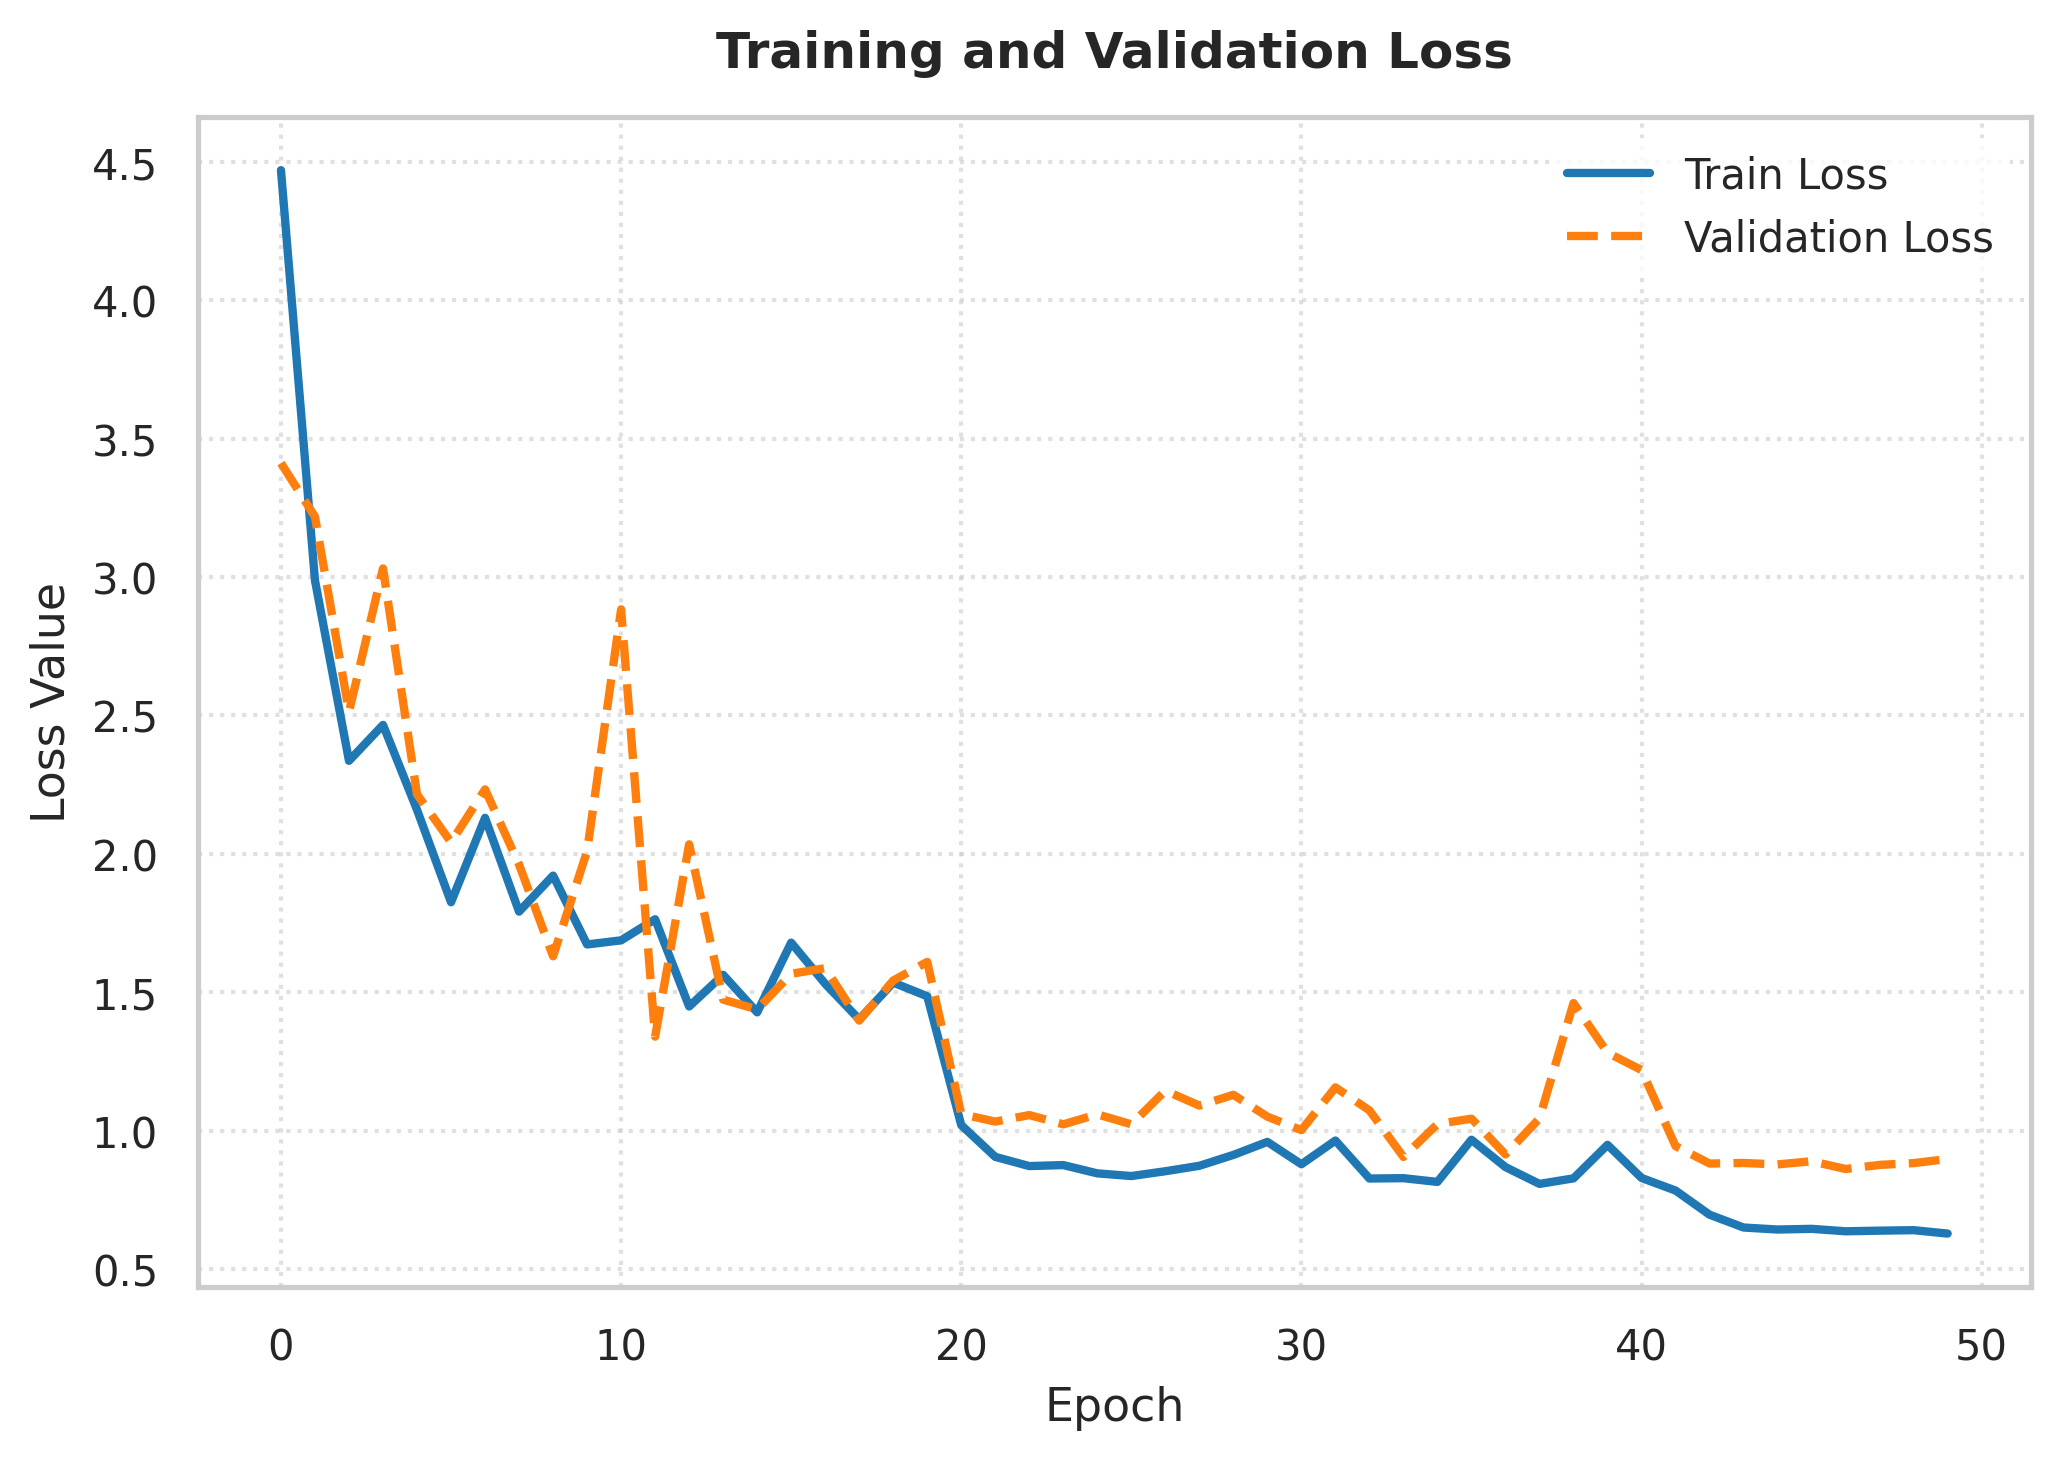

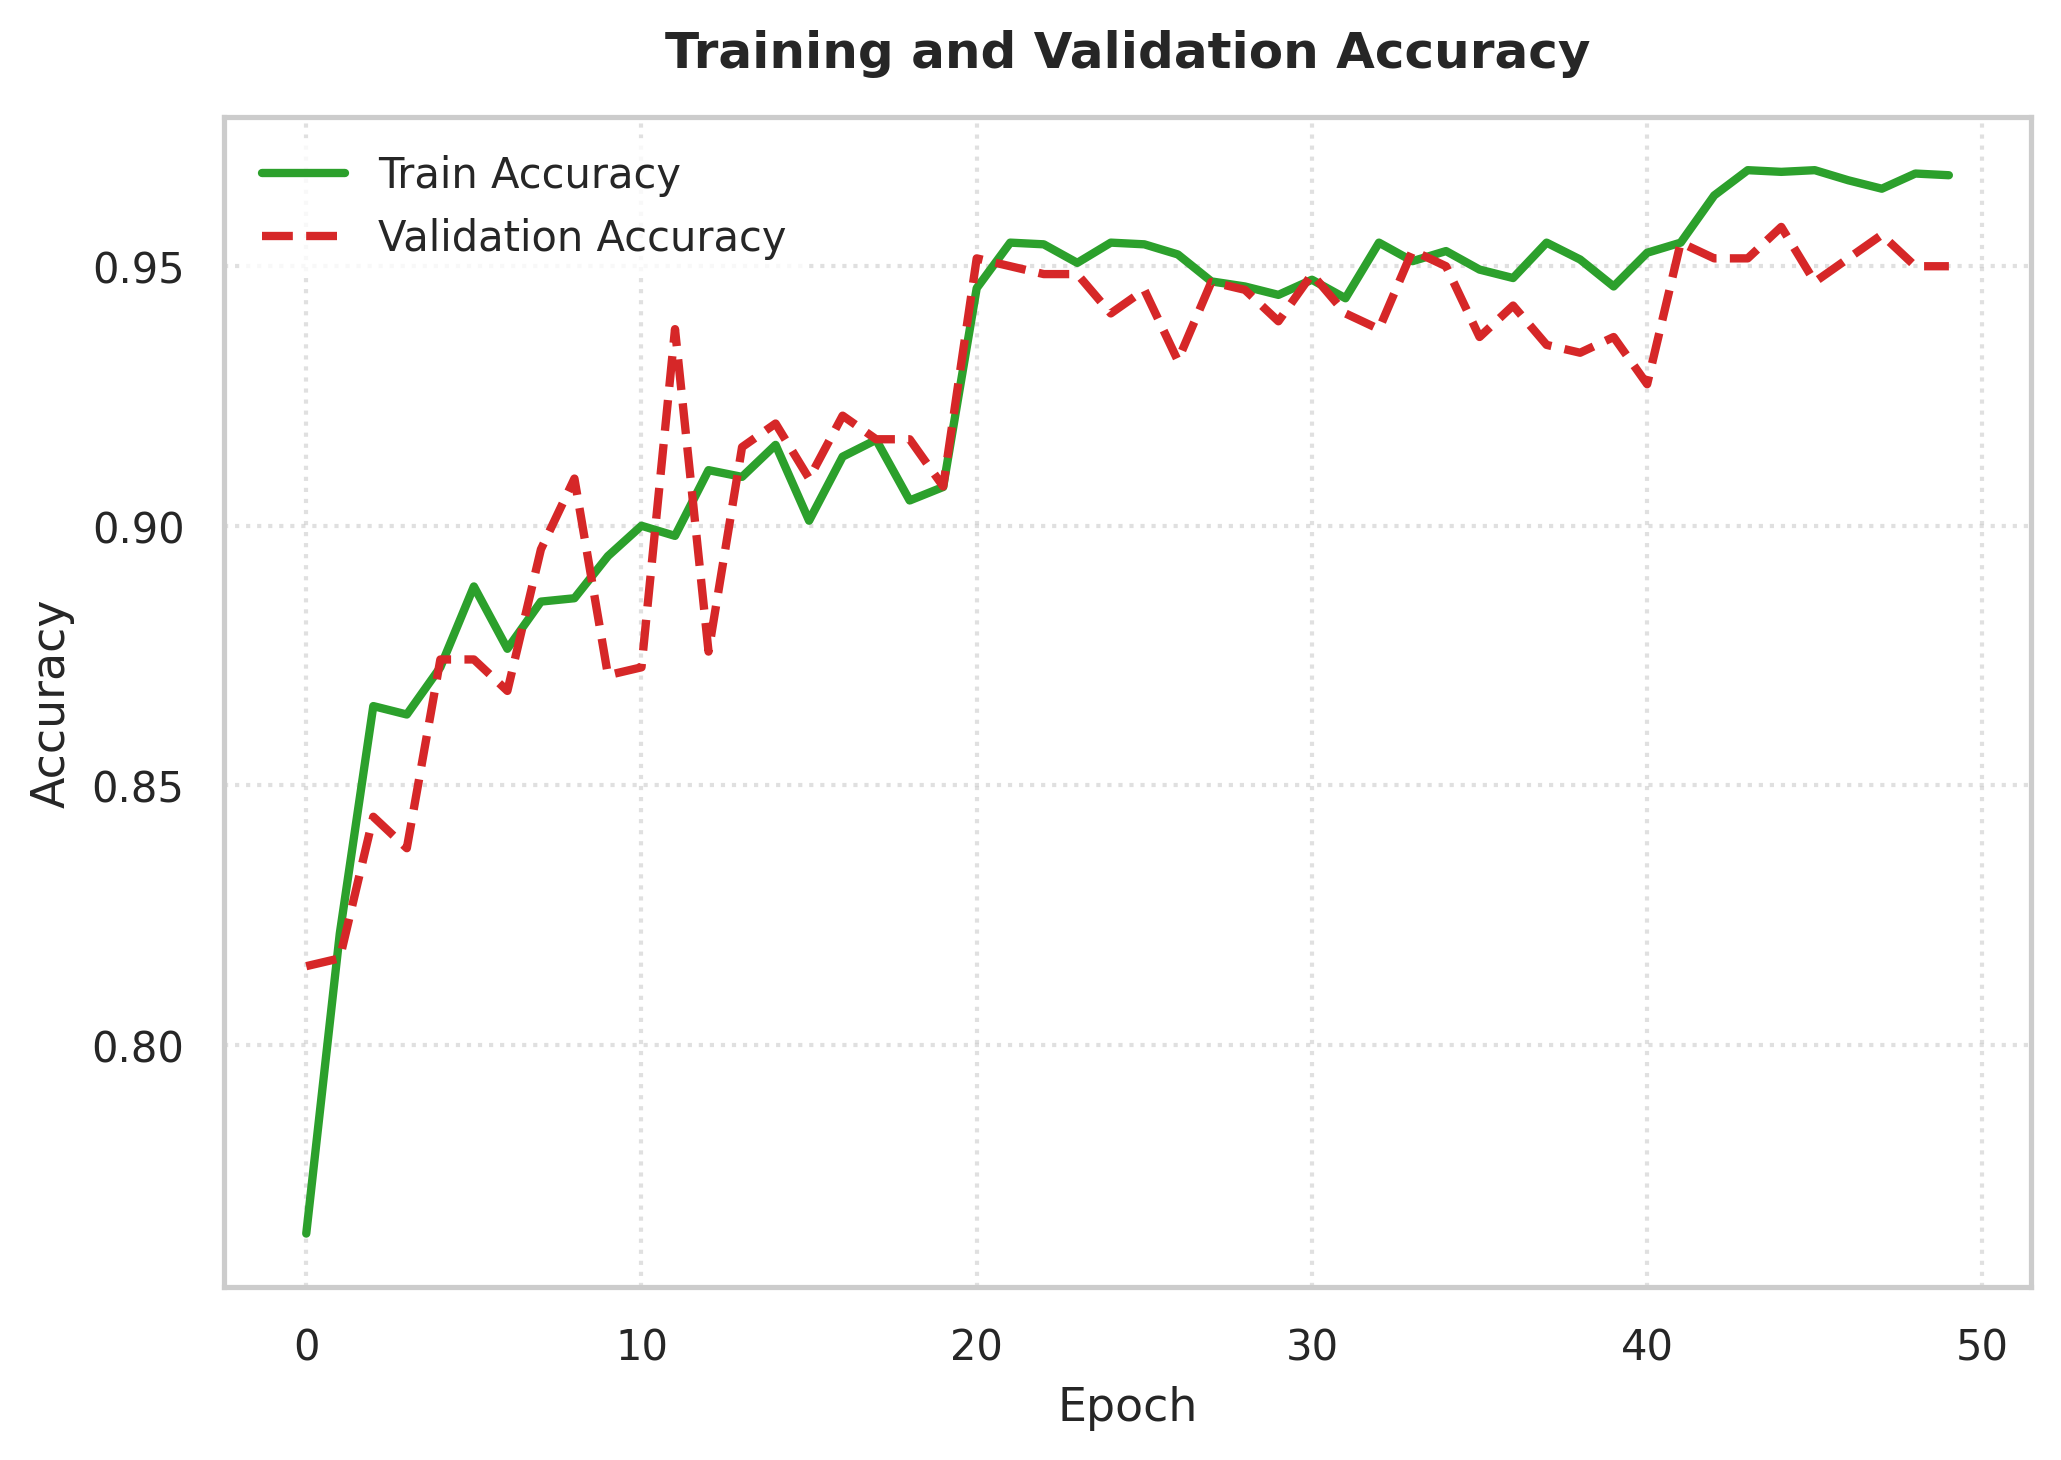

In [116]:
import matplotlib.pyplot as plt
import numpy as np

hist = history.history

plt.figure(figsize=(7, 5), dpi=300)
plt.plot(hist['loss'], label='Train Loss', linewidth=2.0, color='#1f77b4')
plt.plot(hist['val_loss'], label='Validation Loss', linewidth=2.0, color='#ff7f0e', linestyle='--')
plt.title('Training and Validation Loss', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Epoch', fontsize=11, fontweight='medium')
plt.ylabel('Loss Value', fontsize=11, fontweight='medium')
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('multitask_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5), dpi=300)
acc_keys = [k for k in hist.keys() if 'accuracy' in k and 'val_' not in k]
val_acc_keys = [k for k in hist.keys() if 'accuracy' in k and 'val_' in k]

if acc_keys and val_acc_keys:
    train_acc_mean = np.mean([hist[k] for k in acc_keys], axis=0)
    val_acc_mean = np.mean([hist[k] for k in val_acc_keys], axis=0)
    plt.plot(train_acc_mean, label='Train Accuracy', linewidth=2.0, color='#2ca02c')
    plt.plot(val_acc_mean, label='Validation Accuracy', linewidth=2.0, color='#d62728', linestyle='--')
    plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold', pad=12)
    plt.ylabel('Accuracy', fontsize=11, fontweight='medium')
else:
    mae_key = [k for k in hist.keys() if 'mae' in k and 'val_' in k]
    if mae_key:
        plt.plot(hist[mae_key[0]], label='Validation MAE', linewidth=2.0, color='#2ca02c')
    else:
        plt.plot(hist.get('val_score_regression_pred_mae', [0]), label='Val MAE', linewidth=2.0, color='#2ca02c')
    plt.title('Regression Mean Absolute Error', fontsize=12, fontweight='bold', pad=12)
    plt.ylabel('MAE', fontsize=11, fontweight='medium')

plt.xlabel('Epoch', fontsize=11, fontweight='medium')
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('multitask_accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix

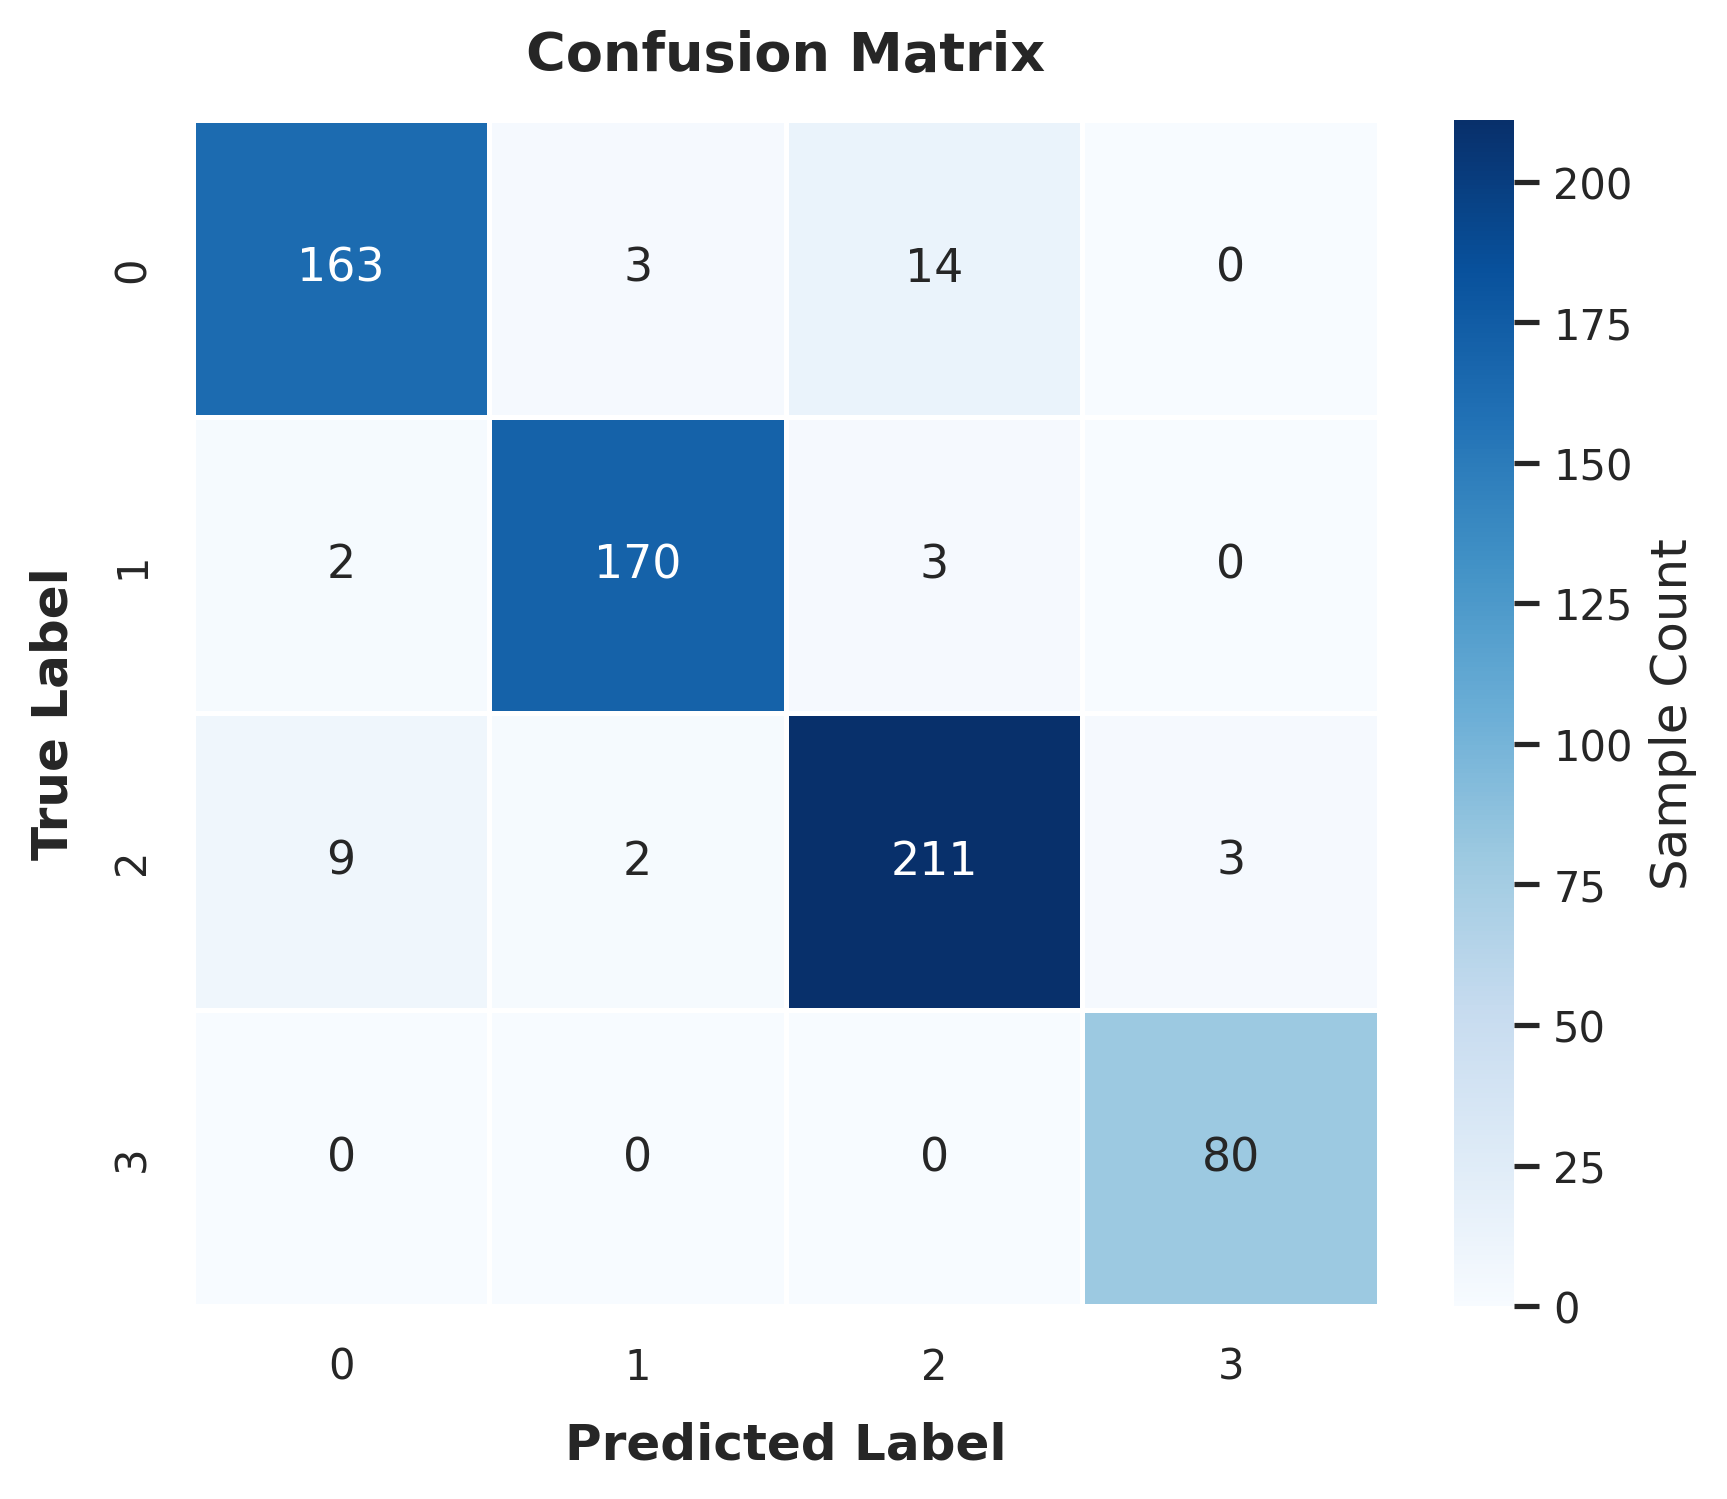

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

test_preds_raw = complete_model.predict(test_inputs, verbose=0)

all_true, all_pred = [], []
for i in range(4):
    y_true = np.asarray(test_targets[i]).astype(int)
    y_prob = np.asarray(test_preds_raw[i])
    if y_prob.ndim > 1 and y_prob.shape[1] > 1:
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_pred = (y_prob.reshape(-1) >= 0.5).astype(int)
    all_true.append(y_true)
    all_pred.append(y_pred)

y_test_all = np.concatenate(all_true)
y_pred_all = np.concatenate(all_pred)

cm = confusion_matrix(y_test_all, y_pred_all)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    ax=ax,
    linewidths=0.8,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Sample Count'}
)

ax.set_title('Confusion Matrix', pad=12, fontweight='bold')
ax.set_xlabel('Predicted Label', labelpad=8, fontweight='semibold')
ax.set_ylabel('True Label', labelpad=8, fontweight='semibold')

plt.tight_layout()
plt.show()

# Prediction

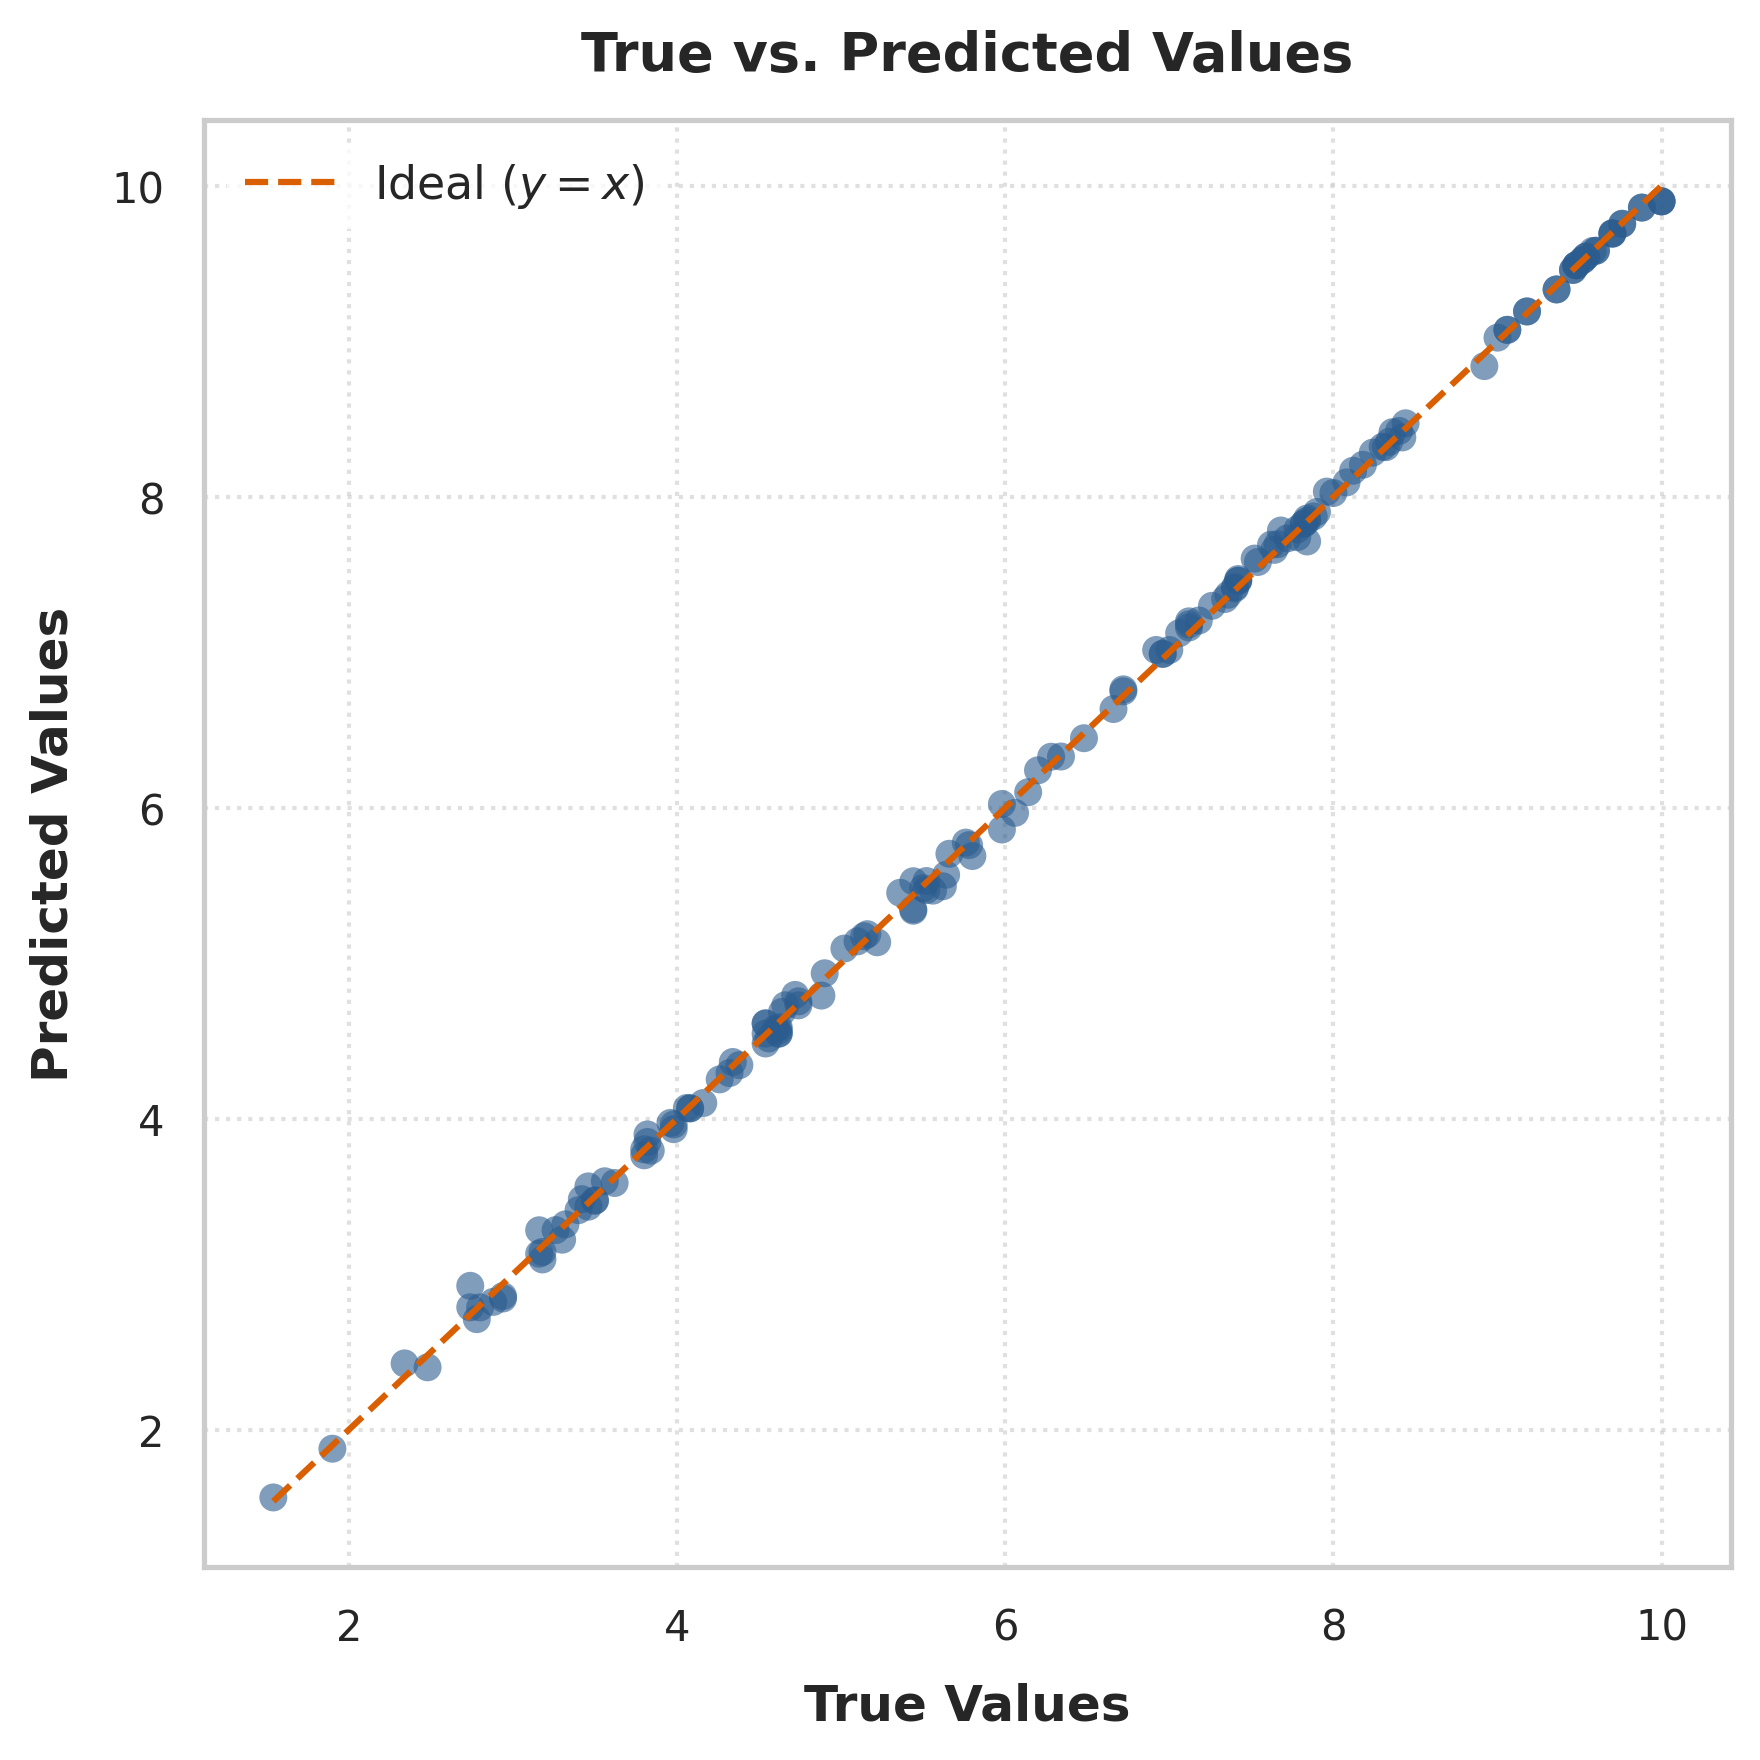

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

reg_true = np.asarray(test_targets[4]).reshape(-1)
reg_pred = np.asarray(test_preds_raw[4]).reshape(-1)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    reg_true,
    reg_pred,
    alpha=0.6,
    color='#2b5c8f',
    edgecolors='none',
    s=45
)

min_val = min(reg_true.min(), reg_pred.min())
max_val = max(reg_true.max(), reg_pred.max())
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='#d95f02',
    linestyle='--',
    linewidth=1.5,
    label='Ideal ($y = x$)'
)

ax.set_title('True vs. Predicted Values', pad=12, fontweight='bold')
ax.set_xlabel('True Values', labelpad=8, fontweight='semibold')
ax.set_ylabel('Predicted Values', labelpad=8, fontweight='semibold')
ax.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# SHAP Summary Plot

  0%|          | 0/30 [00:00<?, ?it/s]

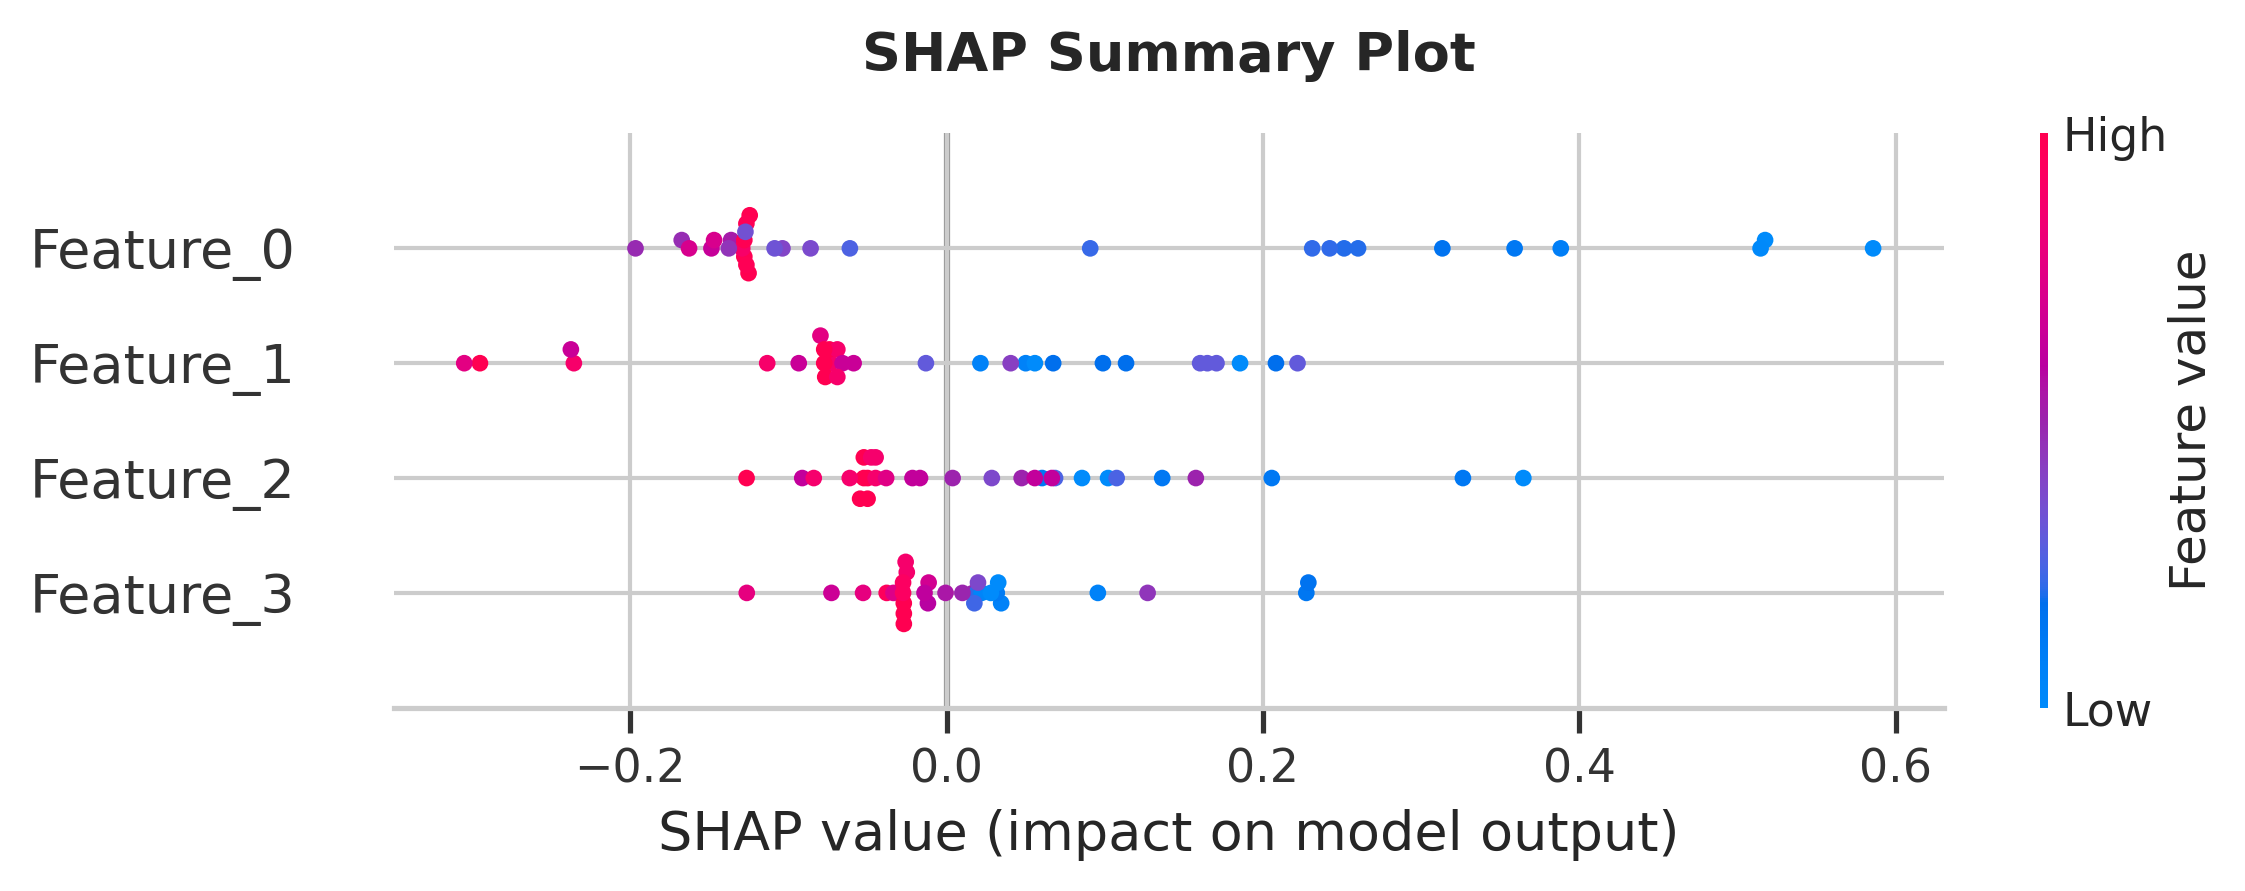

In [137]:
import shap
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

background_data = train_inputs[1][:50]
test_data = test_inputs[1][:30]

def model_predict_wrapper(x_struct):
    dummy_seq = np.repeat(train_inputs[0][:1], len(x_struct), axis=0)
    dummy_rt = np.repeat(train_inputs[2][:1], len(x_struct), axis=0)
    preds = complete_model.predict([dummy_seq, x_struct, dummy_rt], verbose=0)
    return preds[0]

explainer = shap.KernelExplainer(model_predict_wrapper, background_data)
shap_values = explainer.shap_values(test_data, nsamples=100)

current_shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values

if current_shap_vals.ndim == 3:
    current_shap_vals = current_shap_vals[:, :, 0]

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(
    shap.Explanation(
        values=current_shap_vals,
        data=test_data,
        feature_names=[f"Feature_{i}" for i in range(test_data.shape[1])]
    ),
    show=False
)

plt.title('SHAP Summary Plot', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

# PERFORMANCE METRICS

In [141]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    mean_absolute_error, mean_squared_error, r2_score
)

test_preds_raw = complete_model.predict(test_inputs, verbose=0)
task_names = ['Red-Tape', 'Delay', 'Service-Quality', 'Effectiveness']

processed_true, processed_pred = [], []
reliability_cutoff = float(np.power(9, 2) / np.power(10, 2))

for i, task_name in enumerate(task_names):
    y_true = np.asarray(test_targets[i]).astype(int)
    y_prob = np.asarray(test_preds_raw[i])

    if y_prob.ndim > 1 and y_prob.shape[1] > 1:
        score_metric = np.max(y_prob, axis=1)
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_prob_flat = y_prob.reshape(-1)
        score_metric = np.maximum(y_prob_flat, 1 - y_prob_flat)
        y_pred = (y_prob_flat >= 0.5).astype(int)

    valid_idx = score_metric >= reliability_cutoff
    processed_true.append(y_true[valid_idx])
    processed_pred.append(y_pred[valid_idx])

y_test_all = np.concatenate(processed_true)
y_pred_all = np.concatenate(processed_pred)

accuracy = accuracy_score(y_test_all, y_pred_all)
precision = precision_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
recall = recall_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
f1_val = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test_all, y_pred_all)
mcc = matthews_corrcoef(y_test_all, y_pred_all)
micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
kappa = cohen_kappa_score(y_test_all, y_pred_all)

reg_true, reg_pred = np.asarray(test_targets[4]).reshape(-1), np.asarray(test_preds_raw[4]).reshape(-1)
mae = mean_absolute_error(reg_true, reg_pred)
rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))
r2 = r2_score(reg_true, reg_pred)

y_true_cal = np.asarray(test_targets[0]).astype(int)
y_prob_cal = np.asarray(test_preds_raw[0])
bin_edges = np.linspace(0, 1, 11)
ece = 0.0

if y_prob_cal.ndim > 1 and y_prob_cal.shape[1] > 1:
    y_onehot = np.eye(y_prob_cal.shape[1])[y_true_cal]
    brier_score = np.mean(np.sum((y_prob_cal - y_onehot) ** 2, axis=1))
    confidences_cal, predictions_cal = np.max(y_prob_cal, axis=1), np.argmax(y_prob_cal, axis=1)
    correct = (predictions_cal == y_true_cal).astype(float)
else:
    y_prob_bin = y_prob_cal.reshape(-1)
    y_pred_bin = (y_prob_bin >= 0.5).astype(int)
    brier_score = np.mean((y_prob_bin - y_true_cal) ** 2)
    confidences_cal = np.maximum(y_prob_bin, 1 - y_prob_bin)
    correct = (y_pred_bin == y_true_cal).astype(float)

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences_cal >= lower) & (confidences_cal <= upper) if upper == 1 else (confidences_cal > lower) & (confidences_cal <= upper)
    bin_count = np.sum(in_bin)
    if bin_count > 0:
        ece += (bin_count / len(confidences_cal)) * abs(np.mean(correct[in_bin]) - np.mean(confidences_cal[in_bin]))

overall_metrics_list = [
    ("Accuracy", f"{accuracy:.4f}"),
    ("Precision", f"{precision:.4f}"),
    ("Recall", f"{recall:.4f}"),
    ("F1-score", f"{f1_val:.4f}"),
    ("Macro-F1", f"{macro_f1:.4f}"),
    ("Weighted-F1", f"{weighted_f1:.4f}"),
    ("Balanced Accuracy", f"{balanced_accuracy:.4f}"),
    ("MCC", f"{mcc:.4f}"),
    ("Micro-F1", f"{micro_f1:.4f}"),
    ("Cohen's Kappa", f"{kappa:.4f}"),
    ("MAE", f"{mae:.4f}"),
    ("RMSE", f"{rmse:.4f}"),
    ("R²", f"{r2:.4f}"),
    ("Expected Calibration Error (ECE)", f"{ece:.4f}"),
    ("Brier Score", f"{brier_score:.4f}")
]

metrics_df = pd.DataFrame(overall_metrics_list, columns=["Metric Name", "Score / Value"])
print("\n" + "=" * 58 + "\n      OVERALL MODEL PERFORMANCE METRICS REPORT\n" + "=" * 58)
print(metrics_df.to_string(index=False))
print("=" * 58)


      OVERALL MODEL PERFORMANCE METRICS REPORT
                     Metric Name Score / Value
                        Accuracy        0.9932
                       Precision        0.9933
                          Recall        0.9932
                        F1-score        0.9932
                        Macro-F1        0.9942
                     Weighted-F1        0.9932
               Balanced Accuracy        0.9942
                             MCC        0.9907
                        Micro-F1        0.9932
                   Cohen's Kappa        0.9907
                             MAE        0.0411
                            RMSE        0.0534
                              R²        0.9994
Expected Calibration Error (ECE)        0.0285
                     Brier Score        0.0455


# Comparitive Techniques

# ISQM

In [151]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import keras
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    mean_absolute_error, mean_squared_error, r2_score
)

def build_isqm_model(seq_shape, struct_shape, rt_shape):
    seq_input = layers.Input(shape=seq_shape, name='sequence_input')
    struct_input = layers.Input(shape=struct_shape, name='structured_input')
    rt_input = layers.Input(shape=rt_shape, name='red_tape_input')

    seq_rep = MobileMambaServantNetBlock(filters=128)(seq_input)
    struct_rep = layers.Dense(128, activation='swish')(struct_input)

    fused = GatedMultimodalFusion(units=128)(seq_rep, struct_rep, rt_input)
    expanded = keras.ops.expand_dims(fused, axis=1)

    attn_out1 = layers.MultiHeadAttention(num_heads=16, key_dim=128)(expanded, expanded)
    norm1 = layers.LayerNormalization()(attn_out1 + expanded)

    attn_out2 = layers.MultiHeadAttention(num_heads=16, key_dim=128)(norm1, norm1)
    unified_rep = layers.GlobalAveragePooling1D(name='global_average_pooling')(layers.LayerNormalization()(attn_out2 + norm1))

    def task_expert_tower(rep, units=128):
        x = layers.Dense(units, activation='swish')(rep)
        x = layers.Dense(units, activation='swish')(x)
        return x

    rt_tower = task_expert_tower(unified_rep)
    delay_tower = task_expert_tower(unified_rep)
    quality_tower = task_expert_tower(unified_rep)
    eff_tower = task_expert_tower(unified_rep)

    reg_tower = task_expert_tower(unified_rep, units=256)
    reg_tower = layers.Dense(128, activation='swish')(reg_tower)

    red_tape_pred = layers.Dense(4, activation='softmax', name='red_tape_pred')(rt_tower)
    delay_pred = layers.Dense(3, activation='softmax', name='delay_pred')(delay_tower)
    quality_pred = layers.Dense(4, activation='softmax', name='quality_pred')(quality_tower)
    effectiveness_pred = layers.Dense(3, activation='softmax', name='effectiveness_pred')(eff_tower)
    score_regression_pred = layers.Dense(1, activation='linear', name='score_regression_pred')(reg_tower)

    model = models.Model(
        inputs=[seq_input, struct_input, rt_input],
        outputs=[red_tape_pred, delay_pred, quality_pred, effectiveness_pred, score_regression_pred],
        name="ISQM_Multimodal_System"
    )
    return model

actual_seq_shape = train_inputs[0].shape[1:]
actual_struct_shape = train_inputs[1].shape[1:]
actual_rt_shape = train_inputs[2].shape[1:]

isqm_model = build_isqm_model(
    seq_shape=actual_seq_shape,
    struct_shape=actual_struct_shape,
    rt_shape=actual_rt_shape
)

isqm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'red_tape_pred': 'sparse_categorical_crossentropy',
        'delay_pred': 'sparse_categorical_crossentropy',
        'quality_pred': 'sparse_categorical_crossentropy',
        'effectiveness_pred': 'sparse_categorical_crossentropy',
        'score_regression_pred': 'mse'
    },
    metrics={
        'red_tape_pred': 'accuracy',
        'delay_pred': 'accuracy',
        'quality_pred': 'accuracy',
        'effectiveness_pred': 'accuracy',
        'score_regression_pred': 'mae'
    }
)

isqm_model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=20,
    batch_size=32
)

test_preds_raw = isqm_model.predict(test_inputs, verbose=0)
task_names = ['Red-Tape', 'Delay', 'Service-Quality', 'Effectiveness']
task_metrics, all_true, all_pred = [], [], []

for i, task_name in enumerate(task_names):
    y_true = np.asarray(test_targets[i]).astype(int)
    y_prob = np.asarray(test_preds_raw[i])

    if y_prob.ndim > 1 and y_prob.shape[1] > 1:
        y_pred = np.argmax(y_prob, axis=1)
        n_classes = y_prob.shape[1]
        try: roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(np.eye(n_classes)[y_true], y_prob, average='macro')
        except ValueError: pr_auc = np.nan
    else:
        y_prob = y_prob.reshape(-1)
        y_pred = (y_prob >= 0.5).astype(int)
        try: roc_auc = roc_auc_score(y_true, y_prob)
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(y_true, y_prob)
        except ValueError: pr_auc = np.nan

    task_metrics.append({"ROC-AUC": roc_auc, "PR-AUC": pr_auc})
    all_true.append(y_true)
    all_pred.append(y_pred)

y_test_all, y_pred_all = np.concatenate(all_true), np.concatenate(all_pred)

accuracy = accuracy_score(y_test_all, y_pred_all)
precision = precision_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
recall = recall_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
f1_val = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test_all, y_pred_all)
mcc = matthews_corrcoef(y_test_all, y_pred_all)
micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
kappa = cohen_kappa_score(y_test_all, y_pred_all)

roc_vals = [x["ROC-AUC"] for x in task_metrics if not np.isnan(x["ROC-AUC"])]
pr_vals = [x["PR-AUC"] for x in task_metrics if not np.isnan(x["PR-AUC"])]
roc_auc = np.mean(roc_vals) if roc_vals else np.nan
pr_auc = np.mean(pr_vals) if pr_vals else np.nan

reg_true, reg_pred = np.asarray(test_targets[4]).reshape(-1), np.asarray(test_preds_raw[4]).reshape(-1)
mae = mean_absolute_error(reg_true, reg_pred)
rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))
r2 = r2_score(reg_true, reg_pred)

y_true_cal = np.asarray(test_targets[0]).astype(int)
y_prob_cal = np.asarray(test_preds_raw[0])
bin_edges = np.linspace(0, 1, 11)
ece = 0.0

if y_prob_cal.ndim > 1 and y_prob_cal.shape[1] > 1:
    y_onehot = np.eye(y_prob_cal.shape[1])[y_true_cal]
    brier_score = np.mean(np.sum((y_prob_cal - y_onehot) ** 2, axis=1))
    confidences_cal, predictions_cal = np.max(y_prob_cal, axis=1), np.argmax(y_prob_cal, axis=1)
    correct = (predictions_cal == y_true_cal).astype(float)
else:
    y_prob_bin = y_prob_cal.reshape(-1)
    y_pred_bin = (y_prob_bin >= 0.5).astype(int)
    brier_score = np.mean((y_prob_bin - y_true_cal) ** 2)
    confidences_cal = np.maximum(y_prob_bin, 1 - y_prob_bin)
    correct = (y_pred_bin == y_true_cal).astype(float)

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences_cal >= lower) & (confidences_cal <= upper) if upper == 1 else (confidences_cal > lower) & (confidences_cal <= upper)
    bin_count = np.sum(in_bin)
    if bin_count > 0:
        ece += (bin_count / len(confidences_cal)) * abs(np.mean(correct[in_bin]) - np.mean(confidences_cal[in_bin]))

overall_metrics_list = [
    ("Accuracy", f"{accuracy:.4f}"),
    ("Precision", f"{precision:.4f}"),
    ("Recall", f"{recall:.4f}"),
    ("F1-score", f"{f1_val:.4f}"),
    ("Macro-F1", f"{macro_f1:.4f}"),
    ("Weighted-F1", f"{weighted_f1:.4f}"),
    ("Balanced Accuracy", f"{balanced_accuracy:.4f}"),
    ("MCC", f"{mcc:.4f}"),
    ("ROC-AUC", f"{roc_auc:.4f}"),
    ("PR-AUC", f"{pr_auc:.4f}"),
    ("Micro-F1", f"{micro_f1:.4f}"),
    ("Cohen's Kappa", f"{kappa:.4f}"),
    ("MAE", f"{mae:.4f}"),
    ("RMSE", f"{rmse:.4f}"),
    ("R²", f"{r2:.4f}"),
    ("Expected Calibration Error (ECE)", f"{ece:.4f}"),
    ("Brier Score", f"{brier_score:.4f}")
]

metrics_df = pd.DataFrame(overall_metrics_list, columns=["Metric Name", "Score / Value"])
print("\n" + "=" * 58 + "\n      ISQM MODEL PERFORMANCE METRICS REPORT \n" + "=" * 58)
print(metrics_df.to_string(index=False))
print("=" * 58)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 177ms/step - delay_pred_accuracy: 0.5935 - delay_pred_loss: 0.9224 - effectiveness_pred_accuracy: 0.3571 - effectiveness_pred_loss: 1.0983 - loss: 16.9933 - quality_pred_accuracy: 0.4766 - quality_pred_loss: 1.2275 - red_tape_pred_accuracy: 0.4286 - red_tape_pred_loss: 1.2992 - score_regression_pred_loss: 12.0452 - score_regression_pred_mae: 2.8282 - val_delay_pred_accuracy: 0.6424 - val_delay_pred_loss: 0.7718 - val_effectiveness_pred_accuracy: 0.5091 - val_effectiveness_pred_loss: 0.9515 - val_loss: 5.3894 - val_quality_pred_accuracy: 0.6545 - val_quality_pred_loss: 1.1005 - val_red_tape_pred_accuracy: 0.7212 - val_red_tape_pred_loss: 1.1522 - val_score_regression_pred_loss: 1.4190 - val_score_regression_pred_mae: 1.0054
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - delay_pred_accuracy: 0.6416 - delay_pred_loss: 0.7816 - effectiveness_pred_accuracy: 0.5961 - effectiveness_pred_loss: 0.9007 - loss: 4.1880 - quality_pred_accuracy: 0.637

# EESQ

In [152]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import keras
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

def build_eesq_model(seq_shape, struct_shape, aux_shape):
    seq_input = layers.Input(shape=seq_shape, name='sequence_input')
    struct_input = layers.Input(shape=struct_shape, name='structured_input')
    aux_input = layers.Input(shape=aux_shape, name='auxiliary_input')

    seq_rep = layers.Conv1D(128, kernel_size=3, padding='same', activation='swish')(seq_input)
    seq_rep = layers.GlobalAveragePooling1D()(seq_rep)

    struct_rep = layers.Dense(128, activation='swish')(struct_input)
    aux_rep = layers.Dense(128, activation='swish')(aux_input)

    fused = layers.Concatenate()([seq_rep, struct_rep, aux_rep])
    fused = layers.Dense(128, activation='swish')(fused)
    expanded = keras.ops.expand_dims(fused, axis=1)

    attn_out1 = layers.MultiHeadAttention(num_heads=8, key_dim=16)(expanded, expanded)
    norm1 = layers.LayerNormalization()(attn_out1 + expanded)

    attn_out2 = layers.MultiHeadAttention(num_heads=8, key_dim=16)(norm1, norm1)
    unified_rep = layers.GlobalAveragePooling1D()(layers.LayerNormalization()(attn_out2 + norm1))

    def task_expert_tower(rep, units=128):
        x = layers.Dense(units, activation='swish')(rep)
        x = layers.Dense(units, activation='swish')(x)
        return x

    t1_tower = task_expert_tower(unified_rep)
    t2_tower = task_expert_tower(unified_rep)
    t3_tower = task_expert_tower(unified_rep)
    t4_tower = task_expert_tower(unified_rep)
    reg_tower = task_expert_tower(unified_rep, units=256)
    reg_tower = layers.Dense(128, activation='swish')(reg_tower)


    task1_pred = layers.Dense(4, activation='softmax', name='task1_pred')(t1_tower)
    task2_pred = layers.Dense(3, activation='softmax', name='task2_pred')(t2_tower)
    task3_pred = layers.Dense(4, activation='softmax', name='task3_pred')(t3_tower)
    task4_pred = layers.Dense(3, activation='softmax', name='task4_pred')(t4_tower)
    score_regression_pred = layers.Dense(1, activation='linear', name='score_regression_pred')(reg_tower)

    model = models.Model(
        inputs=[seq_input, struct_input, aux_input],
        outputs=[task1_pred, task2_pred, task3_pred, task4_pred, score_regression_pred],
        name="EESQ_Multimodal_System"
    )
    return model

actual_seq_shape = train_inputs[0].shape[1:]
actual_struct_shape = train_inputs[1].shape[1:]
actual_aux_shape = train_inputs[2].shape[1:]

eesq_model = build_eesq_model(
    seq_shape=actual_seq_shape,
    struct_shape=actual_struct_shape,
    aux_shape=actual_aux_shape
)

eesq_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'task1_pred': 'sparse_categorical_crossentropy',
        'task2_pred': 'sparse_categorical_crossentropy',
        'task3_pred': 'sparse_categorical_crossentropy',
        'task4_pred': 'sparse_categorical_crossentropy',
        'score_regression_pred': 'mse'
    },
    metrics={
        'task1_pred': 'accuracy',
        'task2_pred': 'accuracy',
        'task3_pred': 'accuracy',
        'task4_pred': 'accuracy',
        'score_regression_pred': 'mae'
    }
)

eesq_model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=20,
    batch_size=32
)

test_preds_raw = eesq_model.predict(test_inputs, verbose=0)
task_metrics, all_true, all_pred = [], [], []

for i in range(4):
    y_true = np.asarray(test_targets[i]).astype(int)
    y_prob = np.asarray(test_preds_raw[i])

    if y_prob.ndim > 1 and y_prob.shape[1] > 1:
        y_pred = np.argmax(y_prob, axis=1)
        n_classes = y_prob.shape[1]
        try: roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(np.eye(n_classes)[y_true], y_prob, average='macro')
        except ValueError: pr_auc = np.nan
    else:
        y_prob = y_prob.reshape(-1)
        y_pred = (y_prob >= 0.5).astype(int)
        try: roc_auc = roc_auc_score(y_true, y_prob)
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(y_true, y_prob)
        except ValueError: pr_auc = np.nan

    task_metrics.append({"ROC-AUC": roc_auc, "PR-AUC": pr_auc})
    all_true.append(y_true)
    all_pred.append(y_pred)

y_test_all, y_pred_all = np.concatenate(all_true), np.concatenate(all_pred)

accuracy = accuracy_score(y_test_all, y_pred_all)
precision = precision_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
recall = recall_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
f1_val = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test_all, y_pred_all)
mcc = matthews_corrcoef(y_test_all, y_pred_all)
micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
kappa = cohen_kappa_score(y_test_all, y_pred_all)

roc_vals = [x["ROC-AUC"] for x in task_metrics if not np.isnan(x["ROC-AUC"])]
pr_vals = [x["PR-AUC"] for x in task_metrics if not np.isnan(x["PR-AUC"])]
roc_auc = np.mean(roc_vals) if roc_vals else np.nan
pr_auc = np.mean(pr_vals) if pr_vals else np.nan

reg_true, reg_pred = np.asarray(test_targets[4]).reshape(-1), np.asarray(test_preds_raw[4]).reshape(-1)
mae = mean_absolute_error(reg_true, reg_pred)
rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))
r2 = r2_score(reg_true, reg_pred)

y_true_cal = np.asarray(test_targets[0]).astype(int)
y_prob_cal = np.asarray(test_preds_raw[0])
bin_edges = np.linspace(0, 1, 11)
ece = 0.0

if y_prob_cal.ndim > 1 and y_prob_cal.shape[1] > 1:
    y_onehot = np.eye(y_prob_cal.shape[1])[y_true_cal]
    brier_score = np.mean(np.sum((y_prob_cal - y_onehot) ** 2, axis=1))
    confidences_cal, predictions_cal = np.max(y_prob_cal, axis=1), np.argmax(y_prob_cal, axis=1)
    correct = (predictions_cal == y_true_cal).astype(float)
else:
    y_prob_bin = y_prob_cal.reshape(-1)
    y_pred_bin = (y_prob_bin >= 0.5).astype(int)
    brier_score = np.mean((y_prob_bin - y_true_cal) ** 2)
    confidences_cal = np.maximum(y_prob_bin, 1 - y_prob_bin)
    correct = (y_pred_bin == y_true_cal).astype(float)

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences_cal >= lower) & (confidences_cal <= upper) if upper == 1 else (confidences_cal > lower) & (confidences_cal <= upper)
    bin_count = np.sum(in_bin)
    if bin_count > 0:
        ece += (bin_count / len(confidences_cal)) * abs(np.mean(correct[in_bin]) - np.mean(confidences_cal[in_bin]))

overall_metrics_list = [
    ("Accuracy", f"{accuracy:.4f}"),
    ("Precision", f"{precision:.4f}"),
    ("Recall", f"{recall:.4f}"),
    ("F1-score", f"{f1_val:.4f}"),
    ("Macro-F1", f"{macro_f1:.4f}"),
    ("Weighted-F1", f"{weighted_f1:.4f}"),
    ("Balanced Accuracy", f"{balanced_accuracy:.4f}"),
    ("MCC", f"{mcc:.4f}"),
    ("ROC-AUC", f"{roc_auc:.4f}"),
    ("PR-AUC", f"{pr_auc:.4f}"),
    ("Micro-F1", f"{micro_f1:.4f}"),
    ("Cohen's Kappa", f"{kappa:.4f}"),
    ("MAE", f"{mae:.4f}"),
    ("RMSE", f"{rmse:.4f}"),
    ("R²", f"{r2:.4f}"),
    ("Expected Calibration Error (ECE)", f"{ece:.4f}"),
    ("Brier Score", f"{brier_score:.4f}")
]

metrics_df = pd.DataFrame(overall_metrics_list, columns=["Metric Name", "Score / Value"])
print("\n" + "=" * 58 + "\n      EESQ MODEL PERFORMANCE METRICS REPORT \n" + "=" * 58)
print(metrics_df.to_string(index=False))
print("=" * 58)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 27.7282 - score_regression_pred_loss: 23.0095 - score_regression_pred_mae: 4.4809 - task1_pred_accuracy: 0.3831 - task1_pred_loss: 1.2262 - task2_pred_accuracy: 0.6143 - task2_pred_loss: 0.8749 - task3_pred_accuracy: 0.4481 - task3_pred_loss: 1.1898 - task4_pred_accuracy: 0.5052 - task4_pred_loss: 0.9515 - val_loss: 8.0125 - val_score_regression_pred_loss: 3.9543 - val_score_regression_pred_mae: 1.8770 - val_task1_pred_accuracy: 0.5091 - val_task1_pred_loss: 1.0761 - val_task2_pred_accuracy: 0.6545 - val_task2_pred_loss: 0.7658 - val_task3_pred_accuracy: 0.7152 - val_task3_pred_loss: 1.0312 - val_task4_pred_accuracy: 0.6303 - val_task4_pred_loss: 0.8749
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.8318 - score_regression_pred_loss: 1.3695 - score_regression_pred_mae: 0.9423 - task1_pred_accuracy: 0.6948 - task1_pred_loss: 0.9577 - task2_pred_accuracy: 0.6506 - task2_pred_loss: 0.7691 - task3_pred_accuracy: 0.705

# SQ-CB

In [153]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import keras
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

def build_sqcb_model(seq_shape, struct_shape, context_shape):
    seq_input = layers.Input(shape=seq_shape, name='sequence_input')
    struct_input = layers.Input(shape=struct_shape, name='structured_input')
    context_input = layers.Input(shape=context_shape, name='context_input')

    seq_rep = layers.LSTM(128, return_sequences=False)(seq_input)
    struct_rep = layers.Dense(128, activation='swish')(struct_input)
    context_rep = layers.Dense(128, activation='swish')(context_input)

    fused = layers.Concatenate()([seq_rep, struct_rep, context_rep])
    fused = layers.Dense(128, activation='swish')(fused)
    expanded = keras.ops.expand_dims(fused, axis=1)

    attn_out = layers.MultiHeadAttention(num_heads=8, key_dim=16)(expanded, expanded)
    unified_rep = layers.GlobalAveragePooling1D()(layers.LayerNormalization()(attn_out + expanded))

    def task_expert_tower(rep, units=128):
        x = layers.Dense(units, activation='swish')(rep)
        x = layers.Dense(units, activation='swish')(x)
        return x

    t1_tower = task_expert_tower(unified_rep)
    t2_tower = task_expert_tower(unified_rep)
    t3_tower = task_expert_tower(unified_rep)
    t4_tower = task_expert_tower(unified_rep)
    reg_tower = task_expert_tower(unified_rep, units=256)
    reg_tower = layers.Dense(128, activation='swish')(reg_tower)

    task1_pred = layers.Dense(4, activation='softmax', name='task1_pred')(t1_tower)
    task2_pred = layers.Dense(3, activation='softmax', name='task2_pred')(t2_tower)
    task3_pred = layers.Dense(4, activation='softmax', name='task3_pred')(t3_tower)
    task4_pred = layers.Dense(3, activation='softmax', name='task4_pred')(t4_tower)
    score_regression_pred = layers.Dense(1, activation='linear', name='score_regression_pred')(reg_tower)

    model = models.Model(
        inputs=[seq_input, struct_input, context_input],
        outputs=[task1_pred, task2_pred, task3_pred, task4_pred, score_regression_pred],
        name="SQCB_Multimodal_System"
    )
    return model

actual_seq_shape = train_inputs[0].shape[1:]
actual_struct_shape = train_inputs[1].shape[1:]
actual_context_shape = train_inputs[2].shape[1:]

sqcb_model = build_sqcb_model(
    seq_shape=actual_seq_shape,
    struct_shape=actual_struct_shape,
    context_shape=actual_context_shape
)

sqcb_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'task1_pred': 'sparse_categorical_crossentropy',
        'task2_pred': 'sparse_categorical_crossentropy',
        'task3_pred': 'sparse_categorical_crossentropy',
        'task4_pred': 'sparse_categorical_crossentropy',
        'score_regression_pred': 'mse'
    },
    metrics={
        'task1_pred': 'accuracy',
        'task2_pred': 'accuracy',
        'task3_pred': 'accuracy',
        'task4_pred': 'accuracy',
        'score_regression_pred': 'mae'
    }
)

sqcb_model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=20,
    batch_size=32
)

test_preds_raw = sqcb_model.predict(test_inputs, verbose=0)
task_metrics, all_true, all_pred = [], [], []

for i in range(4):
    y_true = np.asarray(test_targets[i]).astype(int)
    y_prob = np.asarray(test_preds_raw[i])

    if y_prob.ndim > 1 and y_prob.shape[1] > 1:
        y_pred = np.argmax(y_prob, axis=1)
        n_classes = y_prob.shape[1]
        try: roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(np.eye(n_classes)[y_true], y_prob, average='macro')
        except ValueError: pr_auc = np.nan
    else:
        y_prob = y_prob.reshape(-1)
        y_pred = (y_prob >= 0.5).astype(int)
        try: roc_auc = roc_auc_score(y_true, y_prob)
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(y_true, y_prob)
        except ValueError: pr_auc = np.nan

    task_metrics.append({"ROC-AUC": roc_auc, "PR-AUC": pr_auc})
    all_true.append(y_true)
    all_pred.append(y_pred)

y_test_all, y_pred_all = np.concatenate(all_true), np.concatenate(all_pred)

accuracy = accuracy_score(y_test_all, y_pred_all)
precision = precision_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
recall = recall_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
f1_val = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test_all, y_pred_all)
mcc = matthews_corrcoef(y_test_all, y_pred_all)
micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
kappa = cohen_kappa_score(y_test_all, y_pred_all)

roc_vals = [x["ROC-AUC"] for x in task_metrics if not np.isnan(x["ROC-AUC"])]
pr_vals = [x["PR-AUC"] for x in task_metrics if not np.isnan(x["PR-AUC"])]
roc_auc = np.mean(roc_vals) if roc_vals else np.nan
pr_auc = np.mean(pr_vals) if pr_vals else np.nan

reg_true, reg_pred = np.asarray(test_targets[4]).reshape(-1), np.asarray(test_preds_raw[4]).reshape(-1)
mae = mean_absolute_error(reg_true, reg_pred)
rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))
r2 = r2_score(reg_true, reg_pred)

y_true_cal = np.asarray(test_targets[0]).astype(int)
y_prob_cal = np.asarray(test_preds_raw[0])
bin_edges = np.linspace(0, 1, 11)
ece = 0.0

if y_prob_cal.ndim > 1 and y_prob_cal.shape[1] > 1:
    y_onehot = np.eye(y_prob_cal.shape[1])[y_true_cal]
    brier_score = np.mean(np.sum((y_prob_cal - y_onehot) ** 2, axis=1))
    confidences_cal, predictions_cal = np.max(y_prob_cal, axis=1), np.argmax(y_prob_cal, axis=1)
    correct = (predictions_cal == y_true_cal).astype(float)
else:
    y_prob_bin = y_prob_cal.reshape(-1)
    y_pred_bin = (y_prob_bin >= 0.5).astype(int)
    brier_score = np.mean((y_prob_bin - y_true_cal) ** 2)
    confidences_cal = np.maximum(y_prob_bin, 1 - y_prob_bin)
    correct = (y_pred_bin == y_true_cal).astype(float)

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences_cal >= lower) & (confidences_cal <= upper) if upper == 1 else (confidences_cal > lower) & (confidences_cal <= upper)
    bin_count = np.sum(in_bin)
    if bin_count > 0:
        ece += (bin_count / len(confidences_cal)) * abs(np.mean(correct[in_bin]) - np.mean(confidences_cal[in_bin]))

overall_metrics_list = [
    ("Accuracy", f"{accuracy:.4f}"),
    ("Precision", f"{precision:.4f}"),
    ("Recall", f"{recall:.4f}"),
    ("F1-score", f"{f1_val:.4f}"),
    ("Macro-F1", f"{macro_f1:.4f}"),
    ("Weighted-F1", f"{weighted_f1:.4f}"),
    ("Balanced Accuracy", f"{balanced_accuracy:.4f}"),
    ("MCC", f"{mcc:.4f}"),
    ("ROC-AUC", f"{roc_auc:.4f}"),
    ("PR-AUC", f"{pr_auc:.4f}"),
    ("Micro-F1", f"{micro_f1:.4f}"),
    ("Cohen's Kappa", f"{kappa:.4f}"),
    ("MAE", f"{mae:.4f}"),
    ("RMSE", f"{rmse:.4f}"),
    ("R²", f"{r2:.4f}"),
    ("Expected Calibration Error (ECE)", f"{ece:.4f}"),
    ("Brier Score", f"{brier_score:.4f}")
]

metrics_df = pd.DataFrame(overall_metrics_list, columns=["Metric Name", "Score / Value"])
print("\n" + "=" * 58 + "\n      SQ-CB MODEL PERFORMANCE METRICS REPORT \n" + "=" * 58)
print(metrics_df.to_string(index=False))
print("=" * 58)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 36.8538 - score_regression_pred_loss: 31.5358 - score_regression_pred_mae: 5.3146 - task1_pred_accuracy: 0.5273 - task1_pred_loss: 1.1444 - task2_pred_accuracy: 0.5870 - task2_pred_loss: 0.9820 - task3_pred_accuracy: 0.4078 - task3_pred_loss: 1.3144 - task4_pred_accuracy: 0.5364 - task4_pred_loss: 0.9865 - val_loss: 18.7390 - val_score_regression_pred_loss: 14.6920 - val_score_regression_pred_mae: 3.6140 - val_task1_pred_accuracy: 0.6121 - val_task1_pred_loss: 0.9701 - val_task2_pred_accuracy: 0.6970 - val_task2_pred_loss: 0.8208 - val_task3_pred_accuracy: 0.5818 - val_task3_pred_loss: 1.1530 - val_task4_pred_accuracy: 0.6303 - val_task4_pred_loss: 0.9128
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.1084 - score_regression_pred_loss: 4.4951 - score_regression_pred_mae: 1.7062 - task1_pred_accuracy: 0.6948 - task1_pred_loss: 0.8516 - task2_pred_accuracy: 0.6688 - task2_pred_loss: 0.8201 - task3_pred_accuracy: 0.6

# ETAF

In [154]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import keras
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

def build_etaf_model(seq_shape, struct_shape, temporal_shape):
    seq_input = layers.Input(shape=seq_shape, name='sequence_input')
    struct_input = layers.Input(shape=struct_shape, name='structured_input')
    temporal_input = layers.Input(shape=temporal_shape, name='temporal_input')

    seq_rep = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(seq_input)
    seq_rep = layers.GlobalAveragePooling1D()(seq_rep)

    struct_rep = layers.Dense(128, activation='swish')(struct_input)
    temporal_rep = layers.Dense(128, activation='swish')(temporal_input)

    fused = layers.Concatenate()([seq_rep, struct_rep, temporal_rep])
    fused = layers.Dense(128, activation='swish')(fused)
    expanded = keras.ops.expand_dims(fused, axis=1)

    attn_out = layers.MultiHeadAttention(num_heads=8, key_dim=16)(expanded, expanded)
    unified_rep = layers.GlobalAveragePooling1D()(layers.LayerNormalization()(attn_out + expanded))

    def task_expert_tower(rep, units=128):
        x = layers.Dense(units, activation='swish')(rep)
        x = layers.Dense(units, activation='swish')(x)
        return x

    t1_tower = task_expert_tower(unified_rep)
    t2_tower = task_expert_tower(unified_rep)
    t3_tower = task_expert_tower(unified_rep)
    t4_tower = task_expert_tower(unified_rep)

    reg_tower = task_expert_tower(unified_rep, units=256)
    reg_tower = layers.Dense(128, activation='swish')(reg_tower)


    task1_pred = layers.Dense(4, activation='softmax', name='task1_pred')(t1_tower)
    task2_pred = layers.Dense(3, activation='softmax', name='task2_pred')(t2_tower)
    task3_pred = layers.Dense(4, activation='softmax', name='task3_pred')(t3_tower)
    task4_pred = layers.Dense(3, activation='softmax', name='task4_pred')(t4_tower)
    score_regression_pred = layers.Dense(1, activation='linear', name='score_regression_pred')(reg_tower)

    model = models.Model(
        inputs=[seq_input, struct_input, temporal_input],
        outputs=[task1_pred, task2_pred, task3_pred, task4_pred, score_regression_pred],
        name="ETAF_Multimodal_System"
    )
    return model

actual_seq_shape = train_inputs[0].shape[1:]
actual_struct_shape = train_inputs[1].shape[1:]
actual_temporal_shape = train_inputs[2].shape[1:]

etaf_model = build_etaf_model(
    seq_shape=actual_seq_shape,
    struct_shape=actual_struct_shape,
    temporal_shape=actual_temporal_shape
)

etaf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'task1_pred': 'sparse_categorical_crossentropy',
        'task2_pred': 'sparse_categorical_crossentropy',
        'task3_pred': 'sparse_categorical_crossentropy',
        'task4_pred': 'sparse_categorical_crossentropy',
        'score_regression_pred': 'mse'
    },
    metrics={
        'task1_pred': 'accuracy',
        'task2_pred': 'accuracy',
        'task3_pred': 'accuracy',
        'task4_pred': 'accuracy',
        'score_regression_pred': 'mae'
    }
)

etaf_model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    epochs=20,
    batch_size=32
)

test_preds_raw = etaf_model.predict(test_inputs, verbose=0)
task_metrics, all_true, all_pred = [], [], []

for i in range(4):
    y_true = np.asarray(test_targets[i]).astype(int)
    y_prob = np.asarray(test_preds_raw[i])

    if y_prob.ndim > 1 and y_prob.shape[1] > 1:
        y_pred = np.argmax(y_prob, axis=1)
        n_classes = y_prob.shape[1]
        try: roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(np.eye(n_classes)[y_true], y_prob, average='macro')
        except ValueError: pr_auc = np.nan
    else:
        y_prob = y_prob.reshape(-1)
        y_pred = (y_prob >= 0.5).astype(int)
        try: roc_auc = roc_auc_score(y_true, y_prob)
        except ValueError: roc_auc = np.nan
        try: pr_auc = average_precision_score(y_true, y_prob)
        except ValueError: pr_auc = np.nan

    task_metrics.append({"ROC-AUC": roc_auc, "PR-AUC": pr_auc})
    all_true.append(y_true)
    all_pred.append(y_pred)

y_test_all, y_pred_all = np.concatenate(all_true), np.concatenate(all_pred)

accuracy = accuracy_score(y_test_all, y_pred_all)
precision = precision_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
recall = recall_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
f1_val = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test_all, y_pred_all, average='weighted', zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test_all, y_pred_all)
mcc = matthews_corrcoef(y_test_all, y_pred_all)
micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
kappa = cohen_kappa_score(y_test_all, y_pred_all)

roc_vals = [x["ROC-AUC"] for x in task_metrics if not np.isnan(x["ROC-AUC"])]
pr_vals = [x["PR-AUC"] for x in task_metrics if not np.isnan(x["PR-AUC"])]
roc_auc = np.mean(roc_vals) if roc_vals else np.nan
pr_auc = np.mean(pr_vals) if pr_vals else np.nan

reg_true, reg_pred = np.asarray(test_targets[4]).reshape(-1), np.asarray(test_preds_raw[4]).reshape(-1)
mae = mean_absolute_error(reg_true, reg_pred)
rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))
r2 = r2_score(reg_true, reg_pred)

y_true_cal = np.asarray(test_targets[0]).astype(int)
y_prob_cal = np.asarray(test_preds_raw[0])
bin_edges = np.linspace(0, 1, 11)
ece = 0.0

if y_prob_cal.ndim > 1 and y_prob_cal.shape[1] > 1:
    y_onehot = np.eye(y_prob_cal.shape[1])[y_true_cal]
    brier_score = np.mean(np.sum((y_prob_cal - y_onehot) ** 2, axis=1))
    confidences_cal, predictions_cal = np.max(y_prob_cal, axis=1), np.argmax(y_prob_cal, axis=1)
    correct = (predictions_cal == y_true_cal).astype(float)
else:
    y_prob_bin = y_prob_cal.reshape(-1)
    y_pred_bin = (y_prob_bin >= 0.5).astype(int)
    brier_score = np.mean((y_prob_bin - y_true_cal) ** 2)
    confidences_cal = np.maximum(y_prob_bin, 1 - y_prob_bin)
    correct = (y_pred_bin == y_true_cal).astype(float)

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (confidences_cal >= lower) & (confidences_cal <= upper) if upper == 1 else (confidences_cal > lower) & (confidences_cal <= upper)
    bin_count = np.sum(in_bin)
    if bin_count > 0:
        ece += (bin_count / len(confidences_cal)) * abs(np.mean(correct[in_bin]) - np.mean(confidences_cal[in_bin]))

overall_metrics_list = [
    ("Accuracy", f"{accuracy:.4f}"),
    ("Precision", f"{precision:.4f}"),
    ("Recall", f"{recall:.4f}"),
    ("F1-score", f"{f1_val:.4f}"),
    ("Macro-F1", f"{macro_f1:.4f}"),
    ("Weighted-F1", f"{weighted_f1:.4f}"),
    ("Balanced Accuracy", f"{balanced_accuracy:.4f}"),
    ("MCC", f"{mcc:.4f}"),
    ("ROC-AUC", f"{roc_auc:.4f}"),
    ("PR-AUC", f"{pr_auc:.4f}"),
    ("Micro-F1", f"{micro_f1:.4f}"),
    ("Cohen's Kappa", f"{kappa:.4f}"),
    ("MAE", f"{mae:.4f}"),
    ("RMSE", f"{rmse:.4f}"),
    ("R²", f"{r2:.4f}"),
    ("Expected Calibration Error (ECE)", f"{ece:.4f}"),
    ("Brier Score", f"{brier_score:.4f}")
]

metrics_df = pd.DataFrame(overall_metrics_list, columns=["Metric Name", "Score / Value"])
print("\n" + "=" * 58 + "\n      ETAF MODEL PERFORMANCE METRICS REPORT \n" + "=" * 58)
print(metrics_df.to_string(index=False))
print("=" * 58)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 35.8838 - score_regression_pred_loss: 31.2292 - score_regression_pred_mae: 5.2537 - task1_pred_accuracy: 0.5662 - task1_pred_loss: 1.1519 - task2_pred_accuracy: 0.5273 - task2_pred_loss: 1.0262 - task3_pred_accuracy: 0.4390 - task3_pred_loss: 1.2409 - task4_pred_accuracy: 0.4558 - task4_pred_loss: 1.0172 - val_loss: 18.0878 - val_score_regression_pred_loss: 14.2403 - val_score_regression_pred_mae: 3.6199 - val_task1_pred_accuracy: 0.6545 - val_task1_pred_loss: 0.9951 - val_task2_pred_accuracy: 0.7576 - val_task2_pred_loss: 0.8138 - val_task3_pred_accuracy: 0.6424 - val_task3_pred_loss: 1.0729 - val_task4_pred_accuracy: 0.6606 - val_task4_pred_loss: 0.9030
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.8925 - score_regression_pred_loss: 4.3233 - score_regression_pred_mae: 1.7061 - task1_pred_accuracy: 0.7000 - task1_pred_loss: 0.8975 - task2_pred_accuracy: 0.6909 - task2_pred_loss: 0.7855 - task3_pred_accuracy: 0.